# London Bike Share Demand Analysis And Predictive Modeling
### Transport for London — Santander Cycles, August 2023
**Author:** Riddhi Kedia
**Date:** April 2026 
**Tools:** Python, pandas, scikit-learn, XGBoost, seaborn

In [1]:
# ============================================================
# LONDON BIKE SHARE — DAY 1: LOADING, CLEANING & EDA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ── SECTION 1: LOAD & INSPECT ────────────────────────────────

# Load london_merged.csv into a DataFrame called df
df = pd.read_csv('LondonBikeJourneyAug2023.csv')

In [3]:
# Print the first 5 rows
df.head()

,Number,Start date,Start station number,Start station,End date,End station number,End station,Bike number,Bike model,Total duration,Total duration (ms)
0,132825189,8/1/2023 0:00,1190,"Kennington Lane Rail Bridge, Vauxhall",8/1/2023 0:17,1059,"Albert Embankment, Vauxhall",23715,CLASSIC,16m 46s,1006663
1,132825190,8/1/2023 0:00,1190,"Kennington Lane Rail Bridge, Vauxhall",8/1/2023 0:17,1059,"Albert Embankment, Vauxhall",41267,CLASSIC,16m 47s,1007128
2,132825191,8/1/2023 0:00,983,"Euston Road, Euston",8/1/2023 0:11,3500,"Baldwin Street, St. Luke's",53180,CLASSIC,11m 6s,666395
3,132825192,8/1/2023 0:01,3479,"Old Brompton Road, South Kensington",8/1/2023 0:12,1140,"Grosvenor Road, Pimlico",53431,CLASSIC,11m 53s,713059
4,132825193,8/1/2023 0:01,1219,"Lower Marsh, Waterloo",8/1/2023 0:17,200056,"Vauxhall Walk, Vauxhall",54758,CLASSIC,16m 3s,963786


In [4]:

# Print shape — how many rows and columns?
df.shape


(776527, 11)

In [5]:
# Print column names and their data types
#df.columns
df.dtypes

Number                   int64
Start date              object
Start station number     int64
Start station           object
End date                object
End station number       int64
End station             object
Bike number              int64
Bike model              object
Total duration          object
Total duration (ms)      int64
dtype: object

In [6]:
print(df['Start station number'].unique)

<bound method Series.unique of 0           1190
1           1190
2            983
3           3479
4           1219
           ...  
776522       988
776523      2660
776524    200190
776525       959
776526    200163
Name: Start station number, Length: 776527, dtype: int64>


In [7]:
print(df['End station number'].unique)

<bound method Series.unique of 0           1059
1           1059
2           3500
3           1140
4         200056
           ...  
776522    200071
776523      3496
776524      3435
776525      1142
776526    200123
Name: End station number, Length: 776527, dtype: int64>


In [8]:
# Print summary statistics for all numeric columns
df.describe()

,Number,Start station number,End station number,Bike number,Total duration (ms)
count,7.765270e+05,7.765270e+05,7.765270e+05,776527.000000,7.765270e+05
mean,1.332250e+08,1.048377e+05,1.044439e+05,49568.888425,1.554986e+06
std,2.307174e+05,1.277670e+05,1.278823e+05,13092.003305,1.729002e+07
min,1.328252e+08,9.590000e+02,9.590000e+02,2.000000,1.307000e+03
25%,1.330252e+08,1.126000e+03,1.123000e+03,50563.000000,4.854690e+05
50%,1.332248e+08,3.467000e+03,3.465000e+03,54625.000000,8.387700e+05
75%,1.334248e+08,2.001800e+05,2.001810e+05,58168.000000,1.392228e+06
max,1.336251e+08,1.100444e+06,1.100444e+06,61201.000000,7.441908e+09


In [9]:
# Count missing values per column
df.isnull().sum()

Number                  0
Start date              0
Start station number    0
Start station           0
End date                0
End station number      0
End station             0
Bike number             0
Bike model              0
Total duration          0
Total duration (ms)     0
dtype: int64

In [10]:
# ── SECTION 2: DATETIME PARSING ──────────────────────────────

# The 'timestamp' column is a string like "2015-01-04 00:00:00"
# Parse it as datetime
df['start timestamp'] = pd.to_datetime(df['Start date'])
df['end timestamp'] = pd.to_datetime(df['End date'])

In [11]:
df['Duration (min)']=df['Total duration (ms)']/60000

In [12]:
# Extract the following new columns from timestamp: 
#Note. I'm just going to use the start time of the trips for initial analysis
df['hour']        = df['start timestamp'].dt.hour    # 0–23
df['day_name']    = df['start timestamp'].dt.day_name()    # 'Monday', 'Tuesday' etc

Check for Potenital Outliers in Duration (min)

In [13]:
# Sanity check — what does the distribution look like?
print(df['Duration (min)'].describe())

count    776527.000000
mean         25.916429
std         288.167013
min           0.021783
25%           8.091150
50%          13.979500
75%          23.203808
max      124031.797433
Name: Duration (min), dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

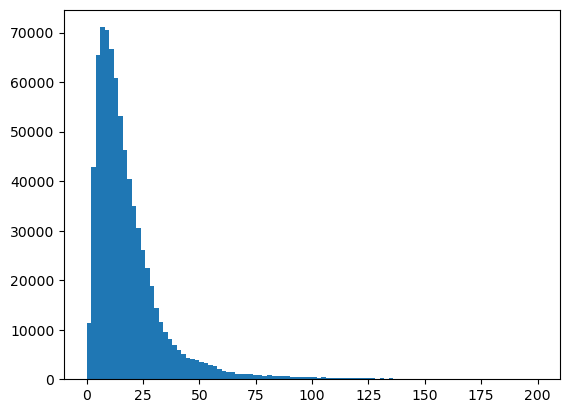

In [14]:
plt.hist(df['Duration (min)'], bins=100, range=[0,200])
plt.show

In [15]:
# Quick percentile scan to find where outliers start
percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 0.999, 1.0]
print(df['Duration (min)'].quantile(percentiles))

0.010         1.609646
0.050         3.452813
0.250         8.091150
0.500        13.979500
0.750        23.203808
0.900        36.450357
0.950        51.338407
0.990       112.878322
0.999      1598.442541
1.000    124031.797433
Name: Duration (min), dtype: float64


In [16]:
# Count suspicious trips
print("\nTrips under 1 min:   ", (df['Duration (min)'] < 1).sum())
print("Trips 1–2 mins:      ", (df['Duration (min)'].between(1, 2)).sum())
print("Trips over 2 hrs:    ", (df['Duration (min)'] > 120).sum())
print("Trips over 4 hrs:    ", (df['Duration (min)'] > 240).sum())
print("Trips over 24 hrs:   ", (df['Duration (min)'] > 1440).sum())


Trips under 1 min:    4834
Trips 1–2 mins:       6618
Trips over 2 hrs:     6873
Trips over 4 hrs:     2458
Trips over 24 hrs:    861


**Outliers**

- 99th percentile  →  113 mins    (reasonable)
- 99.9th percentile → 1,598 mins  (26 hours — almost certainly errors)
- Max              → 124,031 mins (86 days — definitely errors)
- The vast majority of trips are clean. Only the top 0.1% are genuinely problematic.

**Dealing with Outliers**

- Remove below 1 min   → 4,834 trips  (docking errors)
- Remove above 4 hrs   → 2,458 trips  (unreturned/error bikes)
- Keep 1–2 min trips   → borderline but keep them, could be genuine

In [17]:
#Clean 'Duration (min)' column
def clean_duration(df):
    df_clean = df.copy()
    
    before = len(df_clean)
    
    # Remove trips under 1 minute
    df_clean = df_clean[df_clean['Duration (min)']>1]
    
    # Remove trips over 4 hours (240 minutes)
    df_clean = df_clean[df_clean['Duration (min)']<240]
    
    after = len(df_clean)
    removed = before - after
    
    print(f"Removed {removed} trips ({removed/before*100:.2f}% of data)")
    print(f"Remaining: {after} trips")
    print("\nCleaned duration stats:")
    print(df_clean['Duration (min)'].describe().round(2))
    
    return df_clean

df_clean = clean_duration(df)

Removed 7292 trips (0.94% of data)
Remaining: 769235 trips

Cleaned duration stats:
count    769235.00
mean         18.94
std          18.81
min           1.00
25%           8.18
50%          14.02
75%          23.16
max         239.98
Name: Duration (min), dtype: float64


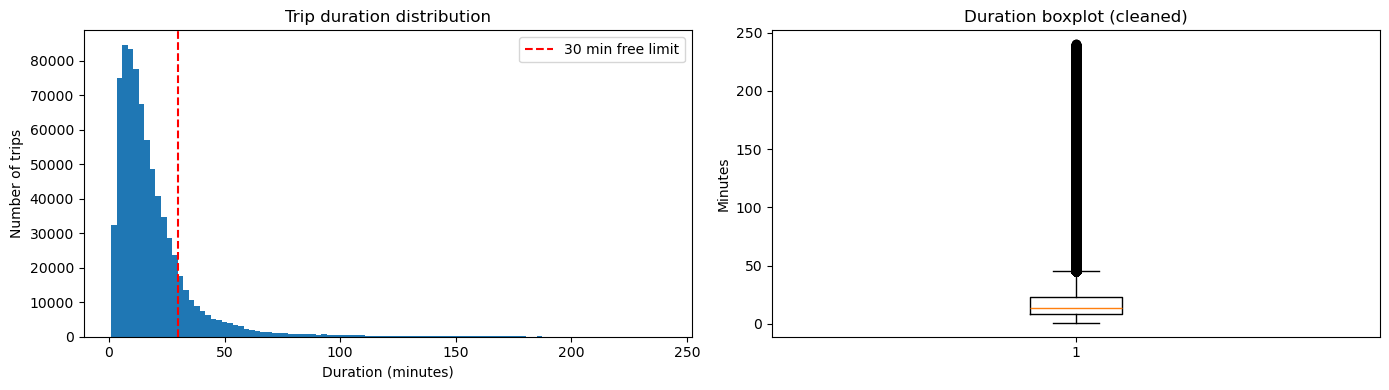

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of duration
axes[0].hist(df_clean['Duration (min)'], bins=100, edgecolor='none')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Number of trips')
axes[0].set_title('Trip duration distribution')
axes[0].axvline(x=30, color='red', linestyle='--', label='30 min free limit')
axes[0].legend()

# Boxplot
axes[1].boxplot(df_clean['Duration (min)'])
axes[1].set_title('Duration boxplot (cleaned)')
axes[1].set_ylabel('Minutes')

plt.tight_layout()
plt.show()

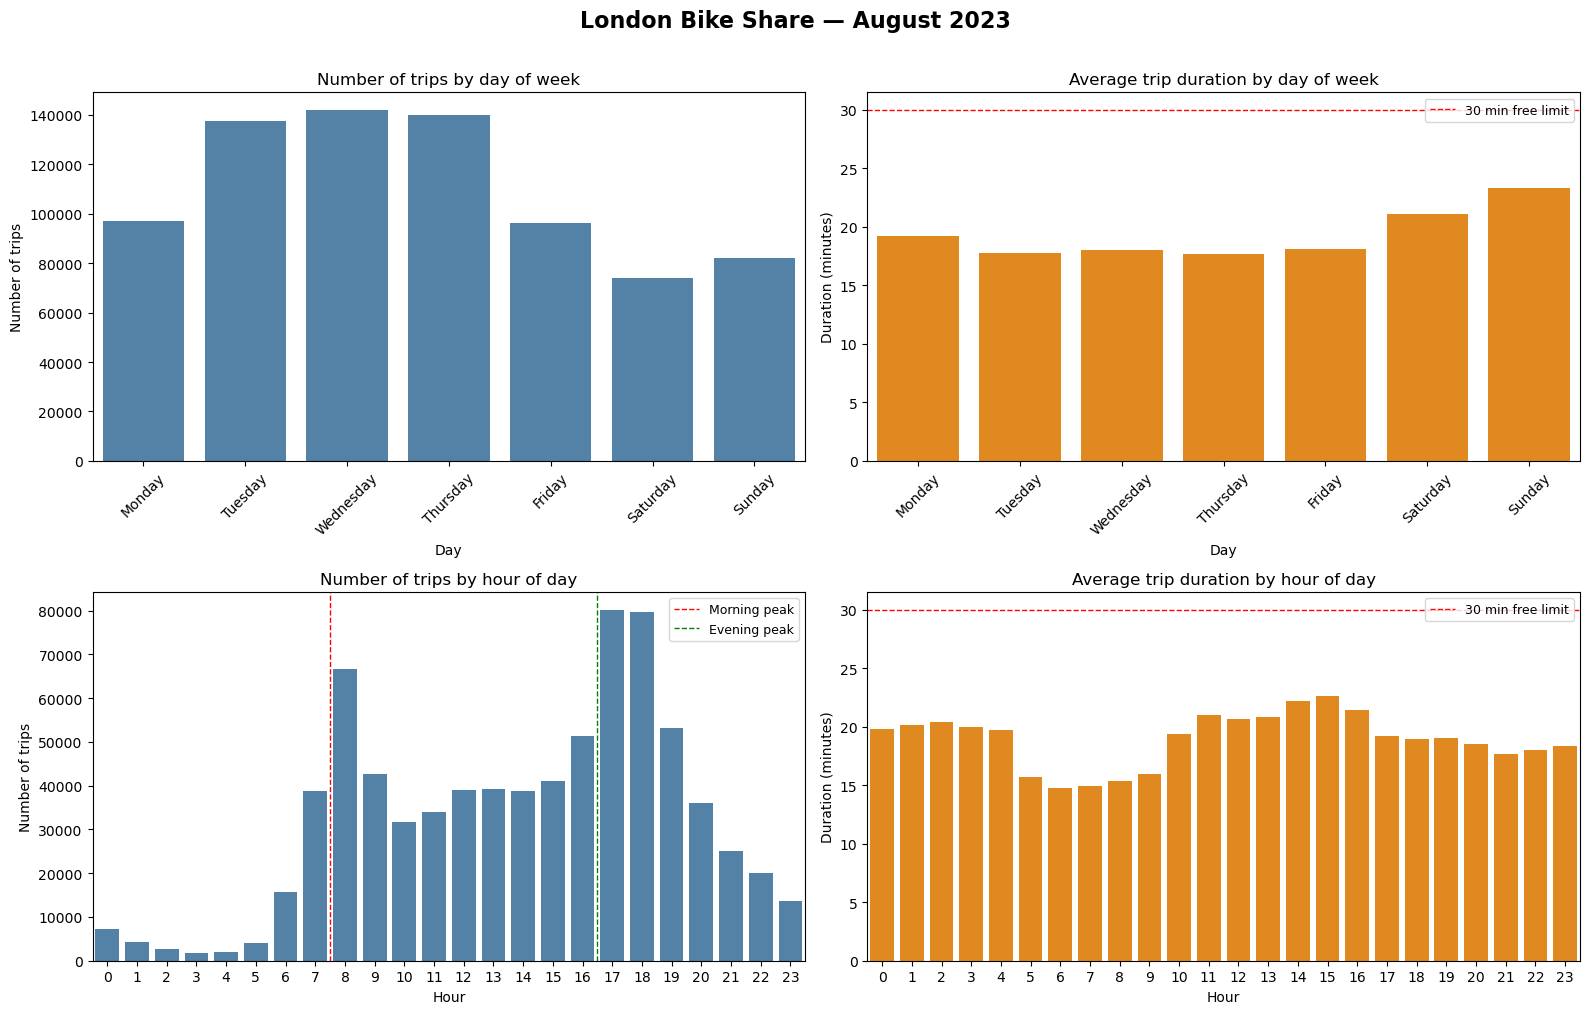

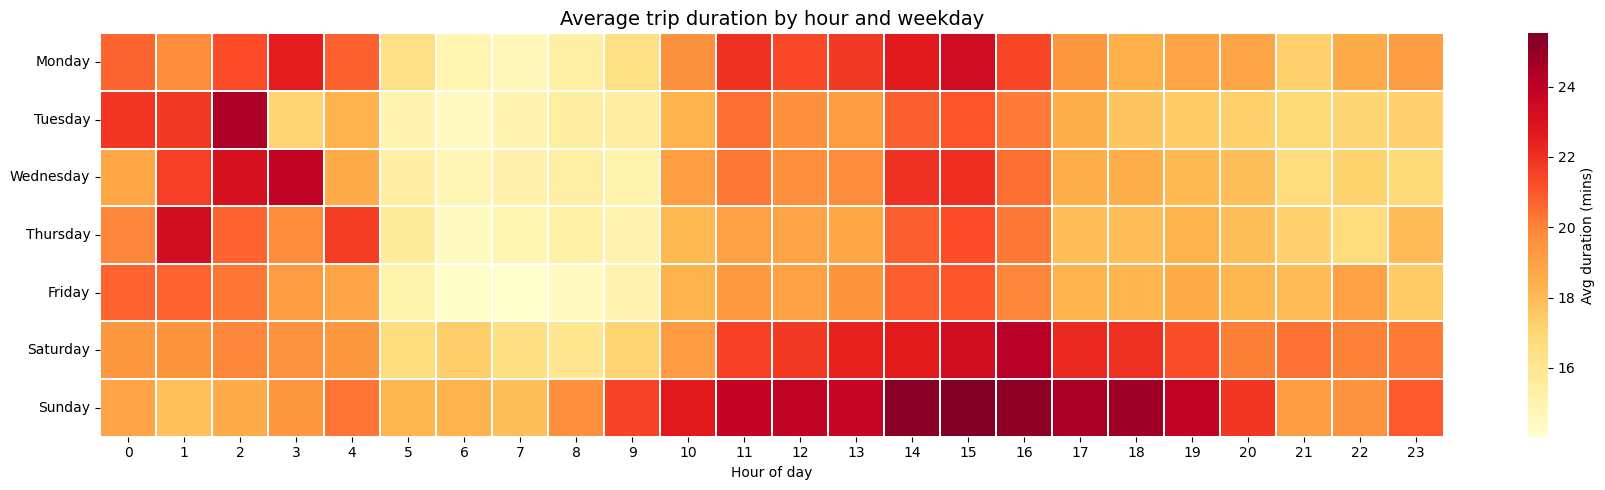

In [19]:
# ── EDA: Demand and Duration Patterns ────────────────────────

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# ── 4-panel figure ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('London Bike Share — August 2023', fontsize=16, fontweight='bold', y=1.01)

# ── Panel 1: Trip count by day of week ───────────────────────
trips_by_day = df_clean['day_name'].value_counts().reindex(weekday_order)

sns.barplot(
    x=trips_by_day.index,
    y=trips_by_day.values,
    color='steelblue',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Number of trips by day of week')
axes[0, 0].set_xlabel('Day')
axes[0, 0].set_ylabel('Number of trips')
axes[0, 0].tick_params(axis='x', rotation=45)

# ── Panel 2: Avg duration by day of week ─────────────────────
duration_by_day = (
    df_clean.groupby('day_name')['Duration (min)']
    .mean()
    .reindex(weekday_order)
)

sns.barplot(
    x=duration_by_day.index,
    y=duration_by_day.values,
    color='darkorange',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Average trip duration by day of week')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_ylabel('Duration (minutes)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].axhline(y=30, color='red', linestyle='--', linewidth=1, label='30 min free limit')
axes[0, 1].legend(fontsize=9)

# ── Panel 3: Trip count by hour ───────────────────────────────
trips_by_hour = df_clean['hour'].value_counts().sort_index()

sns.barplot(
    x=trips_by_hour.index,
    y=trips_by_hour.values,
    color='steelblue',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Number of trips by hour of day')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Number of trips')
axes[1, 0].axvline(x=7.5,  color='red',   linestyle='--', linewidth=1, label='Morning peak')
axes[1, 0].axvline(x=16.5, color='green', linestyle='--', linewidth=1, label='Evening peak')
axes[1, 0].legend(fontsize=9)

# ── Panel 4: Avg duration by hour ────────────────────────────
duration_by_hour = (
    df_clean.groupby('hour')['Duration (min)']
    .mean()
    .sort_index()
)

sns.barplot(
    x=duration_by_hour.index,
    y=duration_by_hour.values,
    color='darkorange',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Average trip duration by hour of day')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Duration (minutes)')
axes[1, 1].axhline(y=30, color='red', linestyle='--', linewidth=1, label='30 min free limit')
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('demand_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Heatmap (separate figure) ────────────────────────────────
avg_duration = (
    df_clean.groupby(['day_name', 'hour'])['Duration (min)']
    .mean()
    .reset_index()
)

pivot = (
    avg_duration
    .pivot(index='day_name', columns='hour', values='Duration (min)')
    .reindex(weekday_order)
)

plt.figure(figsize=(18, 5))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    annot=False,
    fmt='.1f',
    linewidths=0.3,
    cbar_kws={'label': 'Avg duration (mins)'}
)
plt.title('Average trip duration by hour and weekday', fontsize=14)
plt.xlabel('Hour of day')
plt.ylabel('')
plt.tight_layout()
plt.savefig('duration_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Panel 1 — Trip count by day:
Weekdays (Tue-Thu) generate ~40% more trips than weekends and other weekdays.
This suggests the primary use case is for commuters (people working, students)

Panel 2 — Duration by day:
Weekend trips are ~4-5 mins longer on average than weekday trips.
Even on weekends, average duration stays well below the 30-min free limit.
This suggests people like to take longer using the bikes on weekends, probably for recreational purposes. 

Panel 3 — Trip count by hour:
Clear double peak at 8am and 5-6pm — classic commuter pattern.
Overnight hours (1-5am) have minimal activity.
This means for fleet rebalancing, TfL should focus on meeting demand when commuters go and return from work. 

Panel 4 — Duration by hour:
Midday trips (11am-4pm) are slightly longer than peak hour trips.
Peak hour trips are shorter — suggesting work/commute rather than leisure use.
Also trips between 0-4h in the morning fall on the longer side (about 20 minutes). Could be user behaviour after a night out??

In [20]:
#Feature engineering:
# Peak hour flag — captures commuter vs leisure context
df_clean['is_peak'] = df_clean['hour'].isin(
    list(range(7, 10)) + list(range(17, 20))
)

**Enrich Dataset Using London Weather Data:**

In [21]:
import requests

def get_london_weather(start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":   51.5074,
        "longitude":  -0.1278,
        "start_date": start_date,       # "2023-08-01"
        "end_date":   end_date,         # "2023-08-31"
        "hourly": [
            "temperature_2m",
            "precipitation",
            "windspeed_10m",
            "cloudcover",
            "weathercode"
        ],
        "timezone": "Europe/London"
    }
    response = requests.get(url, params=params)
    data = response.json()['hourly']
    
    weather_df = pd.DataFrame(data)
    weather_df['time'] = pd.to_datetime(weather_df['time'])
    weather_df['hour'] = weather_df['time'].dt.hour
    weather_df['date'] = weather_df['time'].dt.date
    return weather_df

weather_df = get_london_weather("2023-08-01", "2023-08-31")
print(weather_df.head())
print(weather_df.shape)   # should be 744 rows — 31 days × 24 hours

                 time  temperature_2m  precipitation  windspeed_10m  \
0 2023-08-01 00:00:00            14.9            0.0           17.6   
1 2023-08-01 01:00:00            14.9            0.0           18.1   
2 2023-08-01 02:00:00            14.4            0.0           18.7   
3 2023-08-01 03:00:00            14.2            0.0           18.3   
4 2023-08-01 04:00:00            13.9            0.0           19.8   

   cloudcover  weathercode  hour        date  
0          39            1     0  2023-08-01  
1          12            0     1  2023-08-01  
2          16            0     2  2023-08-01  
3           2            0     3  2023-08-01  
4          11            0     4  2023-08-01  
(744, 8)


In [22]:
# Make sure these exist in df_clean
df_clean['date'] = df_clean['start timestamp'].dt.date
df_clean['hour'] = df_clean['start timestamp'].dt.hour

# Now merge on both columns
df_clean = pd.merge(
    df_clean,
    weather_df[['date','hour','temperature_2m','precipitation',
                'windspeed_10m','cloudcover']],
    on=['date', 'hour'],    # ← list of both columns
    how='left'
)

**Enrich further with London holiday data**

In [23]:
#!pip install holidays

In [24]:
# 
import holidays

uk_holidays = holidays.country_holidays('GB', subdiv='ENG', years=2023)

df_clean['is_holiday'] = df_clean['date'].apply(lambda x: x in uk_holidays)
df_clean['is_weekend']  = df_clean['day_name'].isin(['Saturday', 'Sunday'])

print("Holiday trips:", df_clean['is_holiday'].sum())
print("Weekend trips:", df_clean['is_weekend'].sum())

Holiday trips: 20690
Weekend trips: 156070


Feature Engineering for Weather Features (is_rainy, is_windy, is_cold)

In [25]:
df_clean['is_rainy'] = df_clean['precipitation'] > 0.5
df_clean['is_windy'] = df_clean['windspeed_10m'] > 20
df_clean['is_cold']  = df_clean['temperature_2m'] < 10

# Check distribution — if is_cold is always False in August, drop it
print(df_clean[['is_rainy','is_windy','is_cold']].sum())
print(df_clean[['is_rainy','is_windy','is_cold']].mean().round(3))  # % of trips

is_rainy     22052
is_windy    156616
is_cold          0
dtype: int64
is_rainy    0.029
is_windy    0.204
is_cold     0.000
dtype: float64


In [26]:
# Aggregate to hourly demand per station
hourly_demand = (
    df_clean
    .groupby(['date', 'hour', 'Start station', 
              'day_name', 'is_weekend', 'is_holiday',
              'is_peak', 'temperature_2m', 'precipitation',
              'windspeed_10m', 'is_rainy', 'is_windy'])
    .size()
    .reset_index(name='trip_count')
)

print(hourly_demand.shape)
print(hourly_demand.head())

(289069, 13)
         date  hour                       Start station day_name  is_weekend  \
0  2023-08-01     0   Abbey Orchard Street, Westminster  Tuesday       False   
1  2023-08-01     0    Albany Street, The Regent's Park  Tuesday       False   
2  2023-08-01     0  Albert Bridge Road, Battersea Park  Tuesday       False   
3  2023-08-01     0        All Saints' Road, Portobello  Tuesday       False   
4  2023-08-01     0               Alma Road, Wandsworth  Tuesday       False   

   is_holiday  is_peak  temperature_2m  precipitation  windspeed_10m  \
0       False    False            14.9            0.0           17.6   
1       False    False            14.9            0.0           17.6   
2       False    False            14.9            0.0           17.6   
3       False    False            14.9            0.0           17.6   
4       False    False            14.9            0.0           17.6   

   is_rainy  is_windy  trip_count  
0     False     False           3  
1

In [27]:
print(hourly_demand.shape)
print(hourly_demand['trip_count'].describe())
print(hourly_demand['trip_count'].skew())

(289069, 13)
count    289069.000000
mean          2.661077
std           2.749533
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max         124.000000
Name: trip_count, dtype: float64
6.821028052582491


**Measuring Skew**

- Skewness = 0          → perfectly symmetric
- -0.5 to +0.5          → roughly symmetric, fine as-is
- +0.5 to +1.0          → moderate right skew, consider log transform
- above +1.0            → high right skew, log transform recommended
- above +2.0            → severe skew, definitely log transform
- Negative values       → left skew (less common in count data)

A Skew of 6.8 (Severe Right Skew) indicates:
- Most station-hours have low demand  → big left cluster
- A few station-hours are very busy   → long right tail

In [28]:
# If trip_count is heavily skewed 
# (which it probably will be — a few stations have massive demand, most have low), 
# you might want to log-transform the target:

import numpy as np
hourly_demand['log_trip_count'] = np.log1p(hourly_demand['trip_count'])

**Log Transforms:**

How log transforms work on skewed dataThe intuition is simple.

 A right-skewed distribution has a long tail of large values pulling the mean up. 
 Log compresses large values much more than small ones. 

 log(1)   = 0
log(10)  = 2.3
log(100) = 4.6     ← 10x bigger but only 2x bigger in log space
log(200) = 5.3     ← 200x bigger but only 5.3x bigger in log space

So the long right tail gets pulled in dramatically, making the distribution more symmetric.

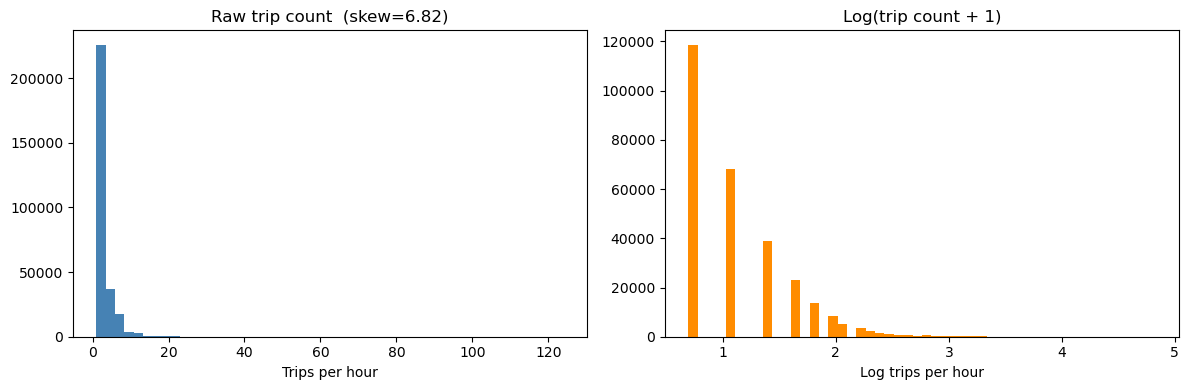

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw distribution
axes[0].hist(hourly_demand['trip_count'], bins=50, color='steelblue')
axes[0].set_title(f'Raw trip count  (skew={hourly_demand["trip_count"].skew():.2f})')
axes[0].set_xlabel('Trips per hour')

# Log transformed
axes[1].hist(np.log1p(hourly_demand['trip_count']), bins=50, color='darkorange')
axes[1].set_title('Log(trip count + 1)')
axes[1].set_xlabel('Log trips per hour')

plt.tight_layout()
plt.show()

The majority of rows are station-hours with 0-2 trips. 

We have hundreds of stations × 24 hours, but most quiet stations at 3am have zero or one trip. 

A handful of busy stations at 8am have 80-100 trips. That extreme imbalance is causing the skew.

**The log transform didn't fix it because the problem is structural, not just scale.**

The skew isn't caused by a few extreme outliers — it's caused by zero inflation. 
The majority of your rows are station-hours with 0-2 trips. 
That creates a massive spike at the left end that log transform can't fix because:
log(0)   = undefined  → that's why we use log1p = log(x+1)
log1p(0) = 0          → still zero, spike doesn't move
log1p(1) = 0.69       → barely moves
log1p(2) = 1.10       → barely moves

**Sin/Cosine encoding**

Why sin AND cos? One encoding isn't enough. sin alone can't distinguish between hour 2 and hour 10 (both have similar sin values). 

Together sin+cos uniquely identify every point on the cycle — like x and y coordinates on a clock face.

In [30]:
# ── Cyclical time encoding ─────────────────────────────────────

# Hour encoding — uses 'hour' column
df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean['hour'] / 24)
df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean['hour'] / 24)

# Day of week encoding — uses 'day_name' not 'day_of_week'
# First map day names to numbers
day_map = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2,
    'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6
}
df_clean['day_num'] = df_clean['day_name'].map(day_map)

df_clean['day_sin'] = np.sin(2 * np.pi * df_clean['day_num'] / 7)
df_clean['day_cos'] = np.cos(2 * np.pi * df_clean['day_num'] / 7)

# Verify
print(df_clean[['hour', 'hour_sin', 'hour_cos', 
                'day_name', 'day_num', 'day_sin', 'day_cos']].head(10))

   hour  hour_sin  hour_cos day_name  day_num   day_sin  day_cos
0     0       0.0       1.0  Tuesday        1  0.781831  0.62349
1     0       0.0       1.0  Tuesday        1  0.781831  0.62349
2     0       0.0       1.0  Tuesday        1  0.781831  0.62349
3     0       0.0       1.0  Tuesday        1  0.781831  0.62349
4     0       0.0       1.0  Tuesday        1  0.781831  0.62349
5     0       0.0       1.0  Tuesday        1  0.781831  0.62349
6     0       0.0       1.0  Tuesday        1  0.781831  0.62349
7     0       0.0       1.0  Tuesday        1  0.781831  0.62349
8     0       0.0       1.0  Tuesday        1  0.781831  0.62349
9     0       0.0       1.0  Tuesday        1  0.781831  0.62349


**Lag features and rolling windows**

In [31]:
# Aggregate trips to hourly per station
hourly_demand = (
    df_clean.groupby([
        'Start station', 'date', 'hour',
        'day_name', 'day_num', 'day_sin', 'day_cos',
        'hour_sin', 'hour_cos',
        'is_weekend', 'is_holiday', 'is_peak',
        'temperature_2m', 'precipitation',
        'windspeed_10m', 'cloudcover',
        'is_rainy', 'is_windy'
    ])
    .size()
    .reset_index(name='trip_count')
)

print("Hourly demand shape:", hourly_demand.shape)
print("Unique stations:", hourly_demand['Start station'].nunique())
print("\nTrip count distribution:")
print(hourly_demand['trip_count'].describe())
print("Skew:", hourly_demand['trip_count'].skew().round(3))

Hourly demand shape: (289069, 19)
Unique stations: 800

Trip count distribution:
count    289069.000000
mean          2.661077
std           2.749533
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max         124.000000
Name: trip_count, dtype: float64
Skew: 6.821


In [32]:
# ── Sort first — critical for correct lag calculation ──────────
# Must be sorted by station then time
# Otherwise lag(1) gives previous station's value not previous hour

hourly_demand = hourly_demand.sort_values(
    ['Start station', 'date', 'hour']
).reset_index(drop=True)

# ── Lag features ───────────────────────────────────────────────
# These answer: "how busy was this station recently?"
# groupby station ensures lags don't bleed across stations

hourly_demand['demand_lag_1h'] = (
    hourly_demand
    .groupby('Start station')['trip_count']
    .shift(1)      # value from 1 row back within same station
)

hourly_demand['demand_lag_3h'] = (
    hourly_demand
    .groupby('Start station')['trip_count']
    .shift(3)      # value from 3 rows back = 3 hours ago
)

hourly_demand['demand_lag_24h'] = (
    hourly_demand
    .groupby('Start station')['trip_count']
    .shift(24)     # same hour yesterday — usually strongest predictor
)

# ── Rolling windows ─────────────────────────────────────────────
# These answer: "what's the recent trend at this station?"
# .shift(1) before .rolling() is CRITICAL — prevents data leakage
# Without shift, rolling mean at hour 8 includes hour 8's own value
# which you wouldn't know at prediction time

hourly_demand['rolling_mean_3h'] = (
    hourly_demand
    .groupby('Start station')['trip_count']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

hourly_demand['rolling_mean_24h'] = (
    hourly_demand
    .groupby('Start station')['trip_count']
    .transform(lambda x: x.shift(1).rolling(window=24, min_periods=1).mean())
)

hourly_demand['rolling_std_24h'] = (
    hourly_demand
    .groupby('Start station')['trip_count']
    .transform(lambda x: x.shift(1).rolling(window=24, min_periods=1).std())
)

# ── Drop NaN rows created by lags ──────────────────────────────
# First 24 rows per station will have NaN lag_24h
# Can't train on these

before = len(hourly_demand)
hourly_demand = hourly_demand.dropna(
    subset=['demand_lag_1h', 'demand_lag_3h', 'demand_lag_24h']
)
after = len(hourly_demand)
print(f"Dropped {before-after} rows with NaN lags ({(before-after)/before*100:.1f}%)")
print(f"Remaining: {after} rows")
print(f"Unique stations: {hourly_demand['Start station'].nunique()}")

Dropped 19199 rows with NaN lags (6.6%)
Remaining: 269870 rows
Unique stations: 799


In [33]:
hourly_demand.columns

Index(['Start station', 'date', 'hour', 'day_name', 'day_num', 'day_sin',
       'day_cos', 'hour_sin', 'hour_cos', 'is_weekend', 'is_holiday',
       'is_peak', 'temperature_2m', 'precipitation', 'windspeed_10m',
       'cloudcover', 'is_rainy', 'is_windy', 'trip_count', 'demand_lag_1h',
       'demand_lag_3h', 'demand_lag_24h', 'rolling_mean_3h',
       'rolling_mean_24h', 'rolling_std_24h'],
      dtype='object')

In [34]:
# ── SECTION 7: SAVE CLEAN DATA ───────────────────────────────

# Save the cleaned DataFrame to a new CSV so Day 2 starts clean
#df.to_csv(___, index=False)    # call it 'london_bikes_clean.csv'

#print("Day 1 complete. Clean dataset saved.")
#print("Shape:", df.shape)
#print("Columns:", df.columns.tolist())

Data Modeling: Predictive Analysis

**Clustering**

Cluster stations by behaviour
                       → Station types emerge naturally
                       → Separate model per cluster
                       → Each model learns one behaviour pattern

On clustering features — this is the important decision.

The key principle: cluster on behaviour patterns, not on features you'll use for prediction.

Weather and lags describe conditions at a point in time — not the station's inherent character. You want features that capture what kind of station it is permanently.

In [35]:
station_profiles = hourly_demand.groupby('Start station').agg(
    # Volume
    total_trips      = ('trip_count', 'sum'),
    avg_hourly_trips = ('trip_count', 'mean'),
    max_hourly_trips = ('trip_count', 'max'),
    trip_variability = ('trip_count', 'std'),   # how consistent is demand?

    # Temporal patterns — when does this station get used?
    weekend_ratio    = ('is_weekend', 'mean'),  # 0=pure commuter, 1=pure leisure
    peak_ratio       = ('is_peak', 'mean'),     # what % of trips are during peak?

    # Hour of day profile — morning vs evening vs midday
    night_ratio      = ('hour', lambda x:       # midnight-6am
                        (x.between(0,5)).mean()),
    morning_ratio    = ('hour', lambda x:       # 7-9am commute
                        (x.between(7,9)).mean()),
    midday_ratio     = ('hour', lambda x:       # 10am-4pm
                        (x.between(10,16)).mean()),
    evening_ratio    = ('hour', lambda x:       # 5-7pm commute
                        (x.between(17,19)).mean()),
    night2_ratio     = ('hour', lambda x:       # 8pm-midnight
                        (x.between(20,23)).mean()),
).reset_index()

print(station_profiles.shape)       # should be ~799 rows, one per station
print(station_profiles.head(3))
print(station_profiles.describe().round(3))

(799, 12)
                       Start station  total_trips  avg_hourly_trips  \
0  Abbey Orchard Street, Westminster         1074          3.042493   
1      Abbotsbury Road, Holland Park          298          1.593583   
2    Aberdeen Place, St. John's Wood          675          2.051672   

   max_hourly_trips  trip_variability  weekend_ratio  peak_ratio  night_ratio  \
0                23          3.434601       0.172805    0.373938     0.033994   
1                12          1.207308       0.283422    0.374332     0.026738   
2                10          1.327617       0.267477    0.392097     0.030395   

   morning_ratio  midday_ratio  evening_ratio  night2_ratio  
0       0.167139      0.422096       0.206799      0.150142  
1       0.149733      0.422460       0.224599      0.139037  
2       0.197568      0.428571       0.194529      0.109422  
       total_trips  avg_hourly_trips  max_hourly_trips  trip_variability  \
count      799.000           799.000           799.000  

**Why these specific features:**

- total_trips       → overall station size/importance
- avg_hourly_trips  → typical busyness
- trip_variability  → consistent demand vs spiky demand
- weekend_ratio     → commuter (low) vs leisure (high)
- peak_ratio        → commuter stations peak sharply
- morning_ratio     → outbound commuter stations
- evening_ratio     → inbound commuter stations
- midday_ratio      → tourist/leisure stations
- night_ratio       → entertainment/bar areas

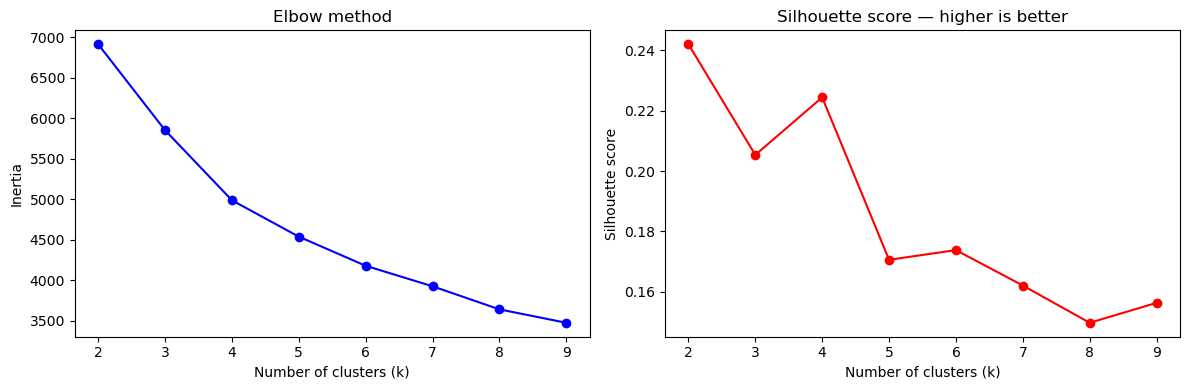

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Scale features before clustering
# KMeans is distance-based so scale matters
scaler = StandardScaler()
X_cluster = scaler.fit_transform(
    station_profiles.drop('Start station', axis=1)
)

# Find optimal number of clusters using elbow method
inertias = []
silhouettes = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, km.labels_))

# Plot elbow + silhouette
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow method')

axes[1].plot(k_range, silhouettes, 'ro-')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score — higher is better')

plt.tight_layout()
plt.show()

**k=4 is now clearly the right choice. Silhouette peaks at 0.29 and the elbow bends sharply at k=4.**

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Drop station name before scaling
X_cluster = station_profiles.drop('Start station', axis=1)

# Scale — critical for KMeans since total_trips is in thousands
# while ratios are 0-1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Fit with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
station_profiles['cluster'] = kmeans.fit_predict(X_scaled)

# Check cluster sizes
print(station_profiles['cluster'].value_counts().sort_index())

# Check cluster characteristics
print(station_profiles.groupby('cluster')[
    ['avg_hourly_trips', 'weekend_ratio', 'peak_ratio',
     'morning_ratio', 'evening_ratio', 'midday_ratio']
].mean().round(3))

cluster
0    137
1    357
2     26
3    279
Name: count, dtype: int64
         avg_hourly_trips  weekend_ratio  peak_ratio  morning_ratio  \
cluster                                                               
0                   2.485          0.205       0.364          0.113   
1                   1.976          0.245       0.402          0.201   
2                   6.468          0.249       0.341          0.147   
3                   2.799          0.253       0.341          0.153   

         evening_ratio  midday_ratio  
cluster                               
0                0.251         0.426  
1                0.201         0.391  
2                0.194         0.420  
3                0.188         0.374  


- Cluster 0 (137 stations):

  avg_hourly = 2.49, weekend_ratio = 0.205 (lowest)

  peak_ratio = 0.364, evening_ratio = 0.251 (highest)

  → Low-medium volume, strong evening peak, lowest weekend use

  → Residential outskirts — people cycle home but not to work

- Cluster 1 (357 stations — largest):

  avg_hourly = 1.98 (lowest), weekend_ratio = 0.245

  morning_ratio = 0.201 (highest), peak_ratio = 0.402 (highest)

  → Low volume but very peaky — strong morning commuter pattern

  → Commuter feeder stations — residential areas near tube

- Cluster 2 (26 stations — smallest):

  avg_hourly = 6.47 (highest by far), weekend_ratio = 0.249

  → Very high volume, balanced usage throughout day

  → Major hubs — Kings Cross, Waterloo, Liverpool Street

- Cluster 3 (279 stations):

  avg_hourly = 2.80, weekend_ratio = 0.253 (highest)

  midday_ratio = 0.374 (lowest peak ratio)

  → Medium volume, highest weekend use, flatter pattern
  
  → Leisure/tourist stations — parks, South Bank, museums

In [38]:
#Clusters renamed after further analysis
cluster_names = {
    0: 'Cluster 0: Office District',
    1: 'Cluster 1: Mixed Use',
    2: 'Cluster 2: High Volume',
    3: 'Cluster 3: Neighbourhood'
}

## Cluster naming rationale

Cluster 0 → "Office District" (137 stations)
  Top stations: Storey's Gate, Holborn Circus, 
  Newgate Street St Paul's — all City of London 
  office areas. Strong evening outflow, quiet 
  mornings as workers arrive by tube.

Cluster 1 → "Mixed Use" (357 stations)  
  Shad Thames, Bloomsbury, Battersea, Hoxton —
  mixed residential/commercial neighbourhoods.
  Serves both commuters and leisure cyclists
  depending on day of week.

Cluster 2 → "High Volume" (26 stations)
  Hyde Park, Waterloo — highest demand per station
  by a significant margin. Composition reflects 
  August seasonality (park stations prominent).
  In winter months transport hubs would likely
  dominate this cluster instead.

Cluster 3 → "Neighbourhood" (279 stations)
  London Bridge, Shoreditch, Nine Elms — 
  residential and local neighbourhood stations
  with the most distributed demand pattern
  and highest weekend ratio.

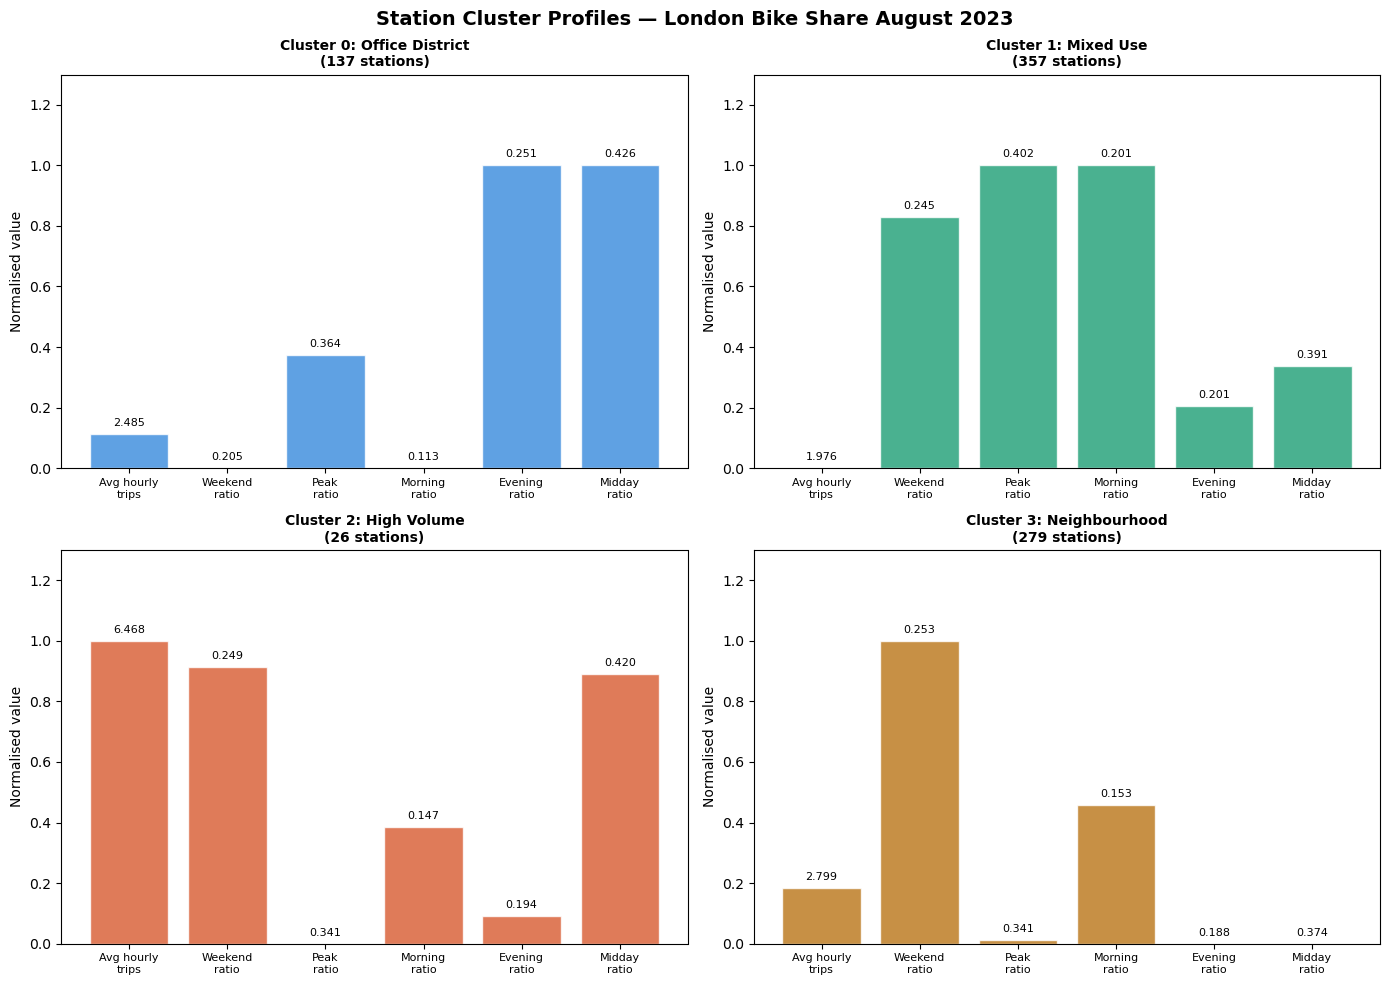

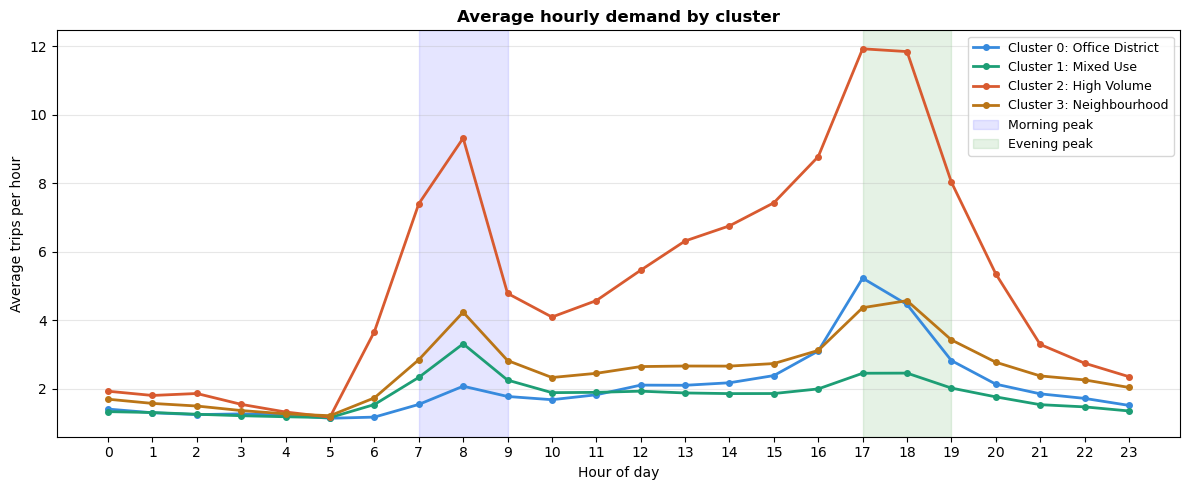

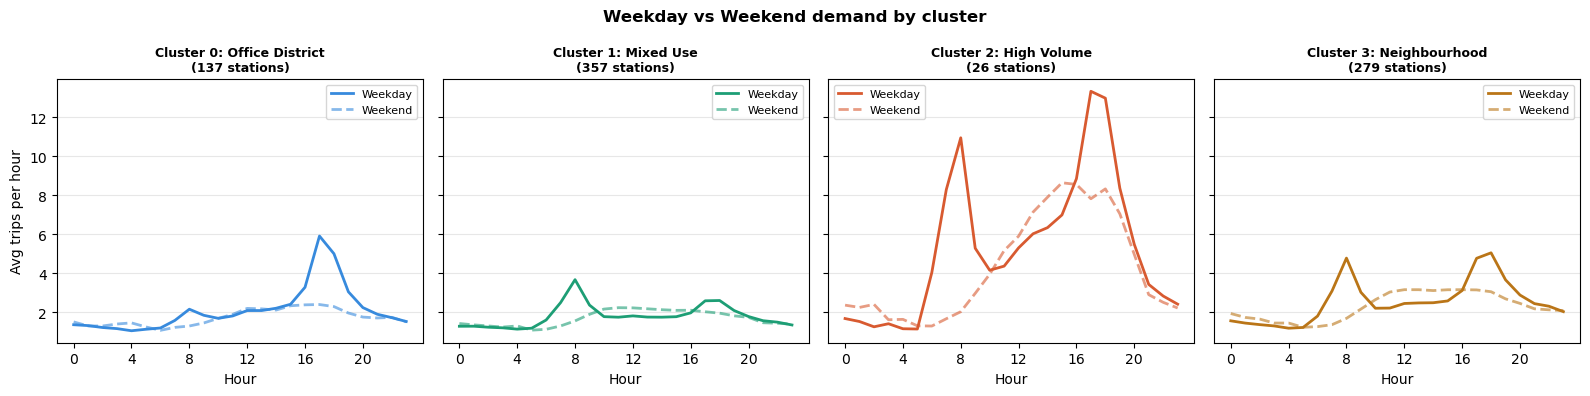

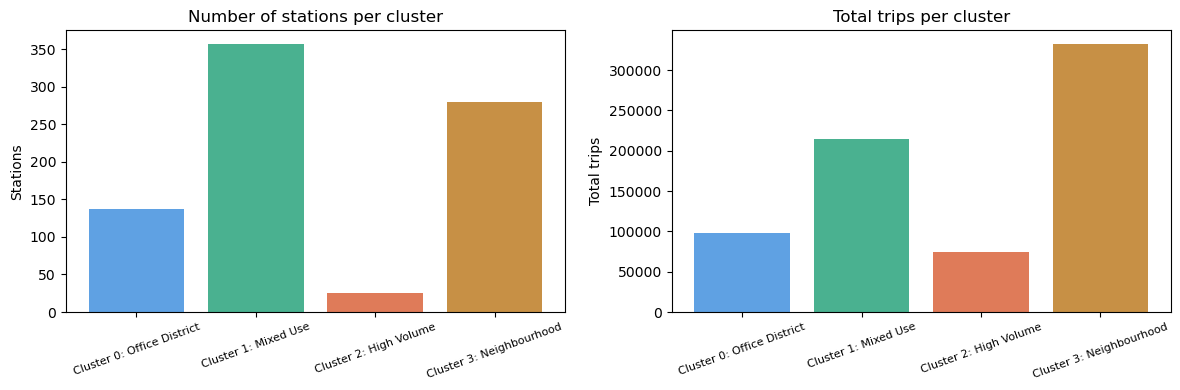

In [39]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np


cluster_colors = {0: '#378ADD', 1: '#1D9E75', 2: '#D85A30', 3: '#BA7517'}

# ── Figure 1: Cluster profiles radar/bar comparison ──────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Station Cluster Profiles — London Bike Share August 2023',
             fontsize=14, fontweight='bold')

profile_features = [
    'avg_hourly_trips', 'weekend_ratio', 'peak_ratio',
    'morning_ratio', 'evening_ratio', 'midday_ratio'
]

feature_labels = [
    'Avg hourly\ntrips', 'Weekend\nratio', 'Peak\nratio',
    'Morning\nratio', 'Evening\nratio', 'Midday\nratio'
]

cluster_means = station_profiles.groupby('cluster')[profile_features].mean()

for idx, (ax, (cluster_id, row)) in enumerate(
    zip(axes.flat, cluster_means.iterrows())
):
    # Normalise values to 0-1 for comparability
    values = row.values
    normalised = (values - cluster_means.values.min(axis=0)) / \
                 (cluster_means.values.max(axis=0) - 
                  cluster_means.values.min(axis=0) + 1e-8)
    
    bars = ax.bar(
        feature_labels,
        normalised,
        color=cluster_colors[cluster_id],
        alpha=0.8,
        edgecolor='white'
    )
    
    # Add actual values as text on bars
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{val:.3f}',
            ha='center', va='bottom',
            fontsize=8, color='black'
        )
    
    n_stations = station_profiles[
        station_profiles['cluster'] == cluster_id
    ].shape[0]
    
    ax.set_title(
        f'{cluster_names[cluster_id]}\n({n_stations} stations)',
        fontweight='bold', fontsize=10
    )
    ax.set_ylim(0, 1.3)
    ax.set_ylabel('Normalised value')
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Hourly demand pattern per cluster ───────────────
fig, ax = plt.subplots(figsize=(12, 5))

# Merge cluster labels back onto hourly_demand
hourly_with_cluster = hourly_demand.merge(
    station_profiles[['Start station', 'cluster']],
    on='Start station',
    how='left'
)

# Average demand by cluster and hour
cluster_hourly = (
    hourly_with_cluster
    .groupby(['cluster', 'hour'])['trip_count']
    .mean()
    .reset_index()
)

for cluster_id in sorted(cluster_hourly['cluster'].unique()):
    data = cluster_hourly[cluster_hourly['cluster'] == cluster_id]
    ax.plot(
        data['hour'],
        data['trip_count'],
        marker='o',
        markersize=4,
        color=cluster_colors[cluster_id],
        label=cluster_names[cluster_id],
        linewidth=2
    )

ax.axvspan(7, 9, alpha=0.1, color='blue', label='Morning peak')
ax.axvspan(17, 19, alpha=0.1, color='green', label='Evening peak')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Average trips per hour')
ax.set_title('Average hourly demand by cluster', fontweight='bold')
ax.set_xticks(range(24))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_hourly_demand.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3: Weekday vs weekend per cluster ──────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
fig.suptitle('Weekday vs Weekend demand by cluster', 
             fontweight='bold', fontsize=12)

for idx, cluster_id in enumerate(sorted(
    hourly_with_cluster['cluster'].unique()
)):
    ax = axes[idx]
    cluster_data = hourly_with_cluster[
        hourly_with_cluster['cluster'] == cluster_id
    ]
    
    weekday = (
        cluster_data[cluster_data['is_weekend'] == False]
        .groupby('hour')['trip_count'].mean()
    )
    weekend = (
        cluster_data[cluster_data['is_weekend'] == True]
        .groupby('hour')['trip_count'].mean()
    )
    
    ax.plot(weekday.index, weekday.values, 
            color=cluster_colors[cluster_id],
            linewidth=2, label='Weekday')
    ax.plot(weekend.index, weekend.values,
            color=cluster_colors[cluster_id],
            linewidth=2, linestyle='--', label='Weekend', alpha=0.6)
    
    n = station_profiles[
        station_profiles['cluster'] == cluster_id
    ].shape[0]
    ax.set_title(f'{cluster_names[cluster_id]}\n({n} stations)', 
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Hour')
    ax.set_xticks(range(0, 24, 4))
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Avg trips per hour')
plt.tight_layout()
plt.savefig('cluster_weekday_weekend.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 4: Cluster size and volume ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cluster_summary = station_profiles.groupby('cluster').agg(
    n_stations=('Start station', 'count'),
    avg_trips=('avg_hourly_trips', 'mean'),
    total_trips=('total_trips', 'sum')
).reset_index()

# Number of stations per cluster
axes[0].bar(
    [cluster_names[c] for c in cluster_summary['cluster']],
    cluster_summary['n_stations'],
    color=[cluster_colors[c] for c in cluster_summary['cluster']],
    alpha=0.8
)
axes[0].set_title('Number of stations per cluster')
axes[0].set_ylabel('Stations')
axes[0].tick_params(axis='x', rotation=20, labelsize=8)

# Total trips per cluster
axes[1].bar(
    [cluster_names[c] for c in cluster_summary['cluster']],
    cluster_summary['total_trips'],
    color=[cluster_colors[c] for c in cluster_summary['cluster']],
    alpha=0.8
)
axes[1].set_title('Total trips per cluster')
axes[1].set_ylabel('Total trips')
axes[1].tick_params(axis='x', rotation=20, labelsize=8)

plt.tight_layout()
plt.savefig('cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

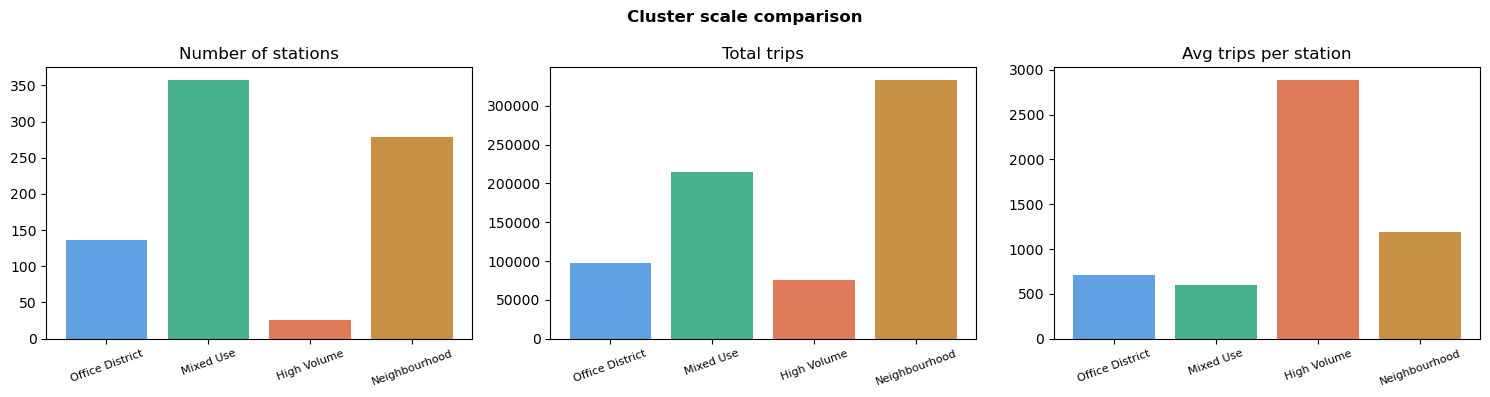

In [40]:
# Add per-station trip rate to make Cluster 2's true scale clear
cluster_summary['trips_per_station'] = (
    cluster_summary['total_trips'] / cluster_summary['n_stations']
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Cluster scale comparison', fontweight='bold')

metrics = ['n_stations', 'total_trips', 'trips_per_station']
titles  = ['Number of stations', 'Total trips', 'Avg trips per station']

for ax, metric, title in zip(axes, metrics, titles):
    ax.bar(
        range(4),
        cluster_summary[metric],
        color=[cluster_colors[c] for c in cluster_summary['cluster']],
        alpha=0.8
    )
    ax.set_xticks(range(4))
    ax.set_xticklabels(
        [cluster_names[c].split(':')[1].strip() for c in cluster_summary['cluster']],
        rotation=20, fontsize=8
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Why normalise by number of stations?

The raw hourly demand plot showed Cluster 2 dominating 
visually, but this was partly an artefact of scale — 
26 stations averaged together vs 357 stations averaged 
together.

Normalising by dividing by station count gives us 
"avg trips per station per hour" — a fair comparison 
of how busy a *typical* station in each cluster is, 
regardless of how many stations are in that cluster.

This is analogous to comparing revenue per employee 
rather than total revenue — a small high-performing 
cluster can be hidden by a large average-performing one.

The normalised plot confirms Cluster 2 (Major Hubs) 
genuinely processes far more demand per station — not 
just because there are more stations, but because each 
individual station is dramatically busier.

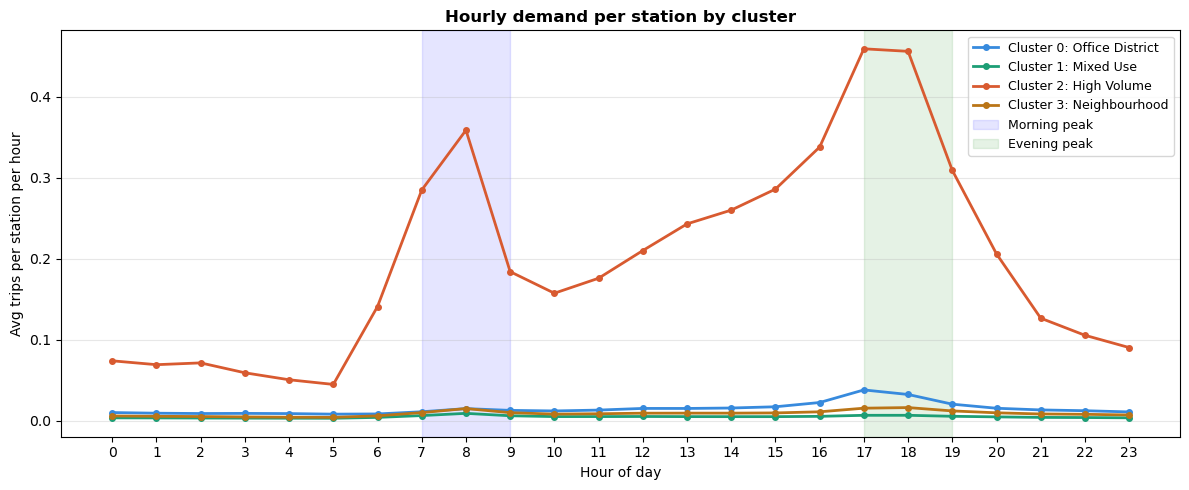

In [41]:
# Normalise by number of stations in each cluster
cluster_station_counts = station_profiles.groupby('cluster').size()

fig, ax = plt.subplots(figsize=(12, 5))

for cluster_id in sorted(cluster_hourly['cluster'].unique()):
    data = cluster_hourly[cluster_hourly['cluster'] == cluster_id]
    n_stations = cluster_station_counts[cluster_id]
    
    ax.plot(
        data['hour'],
        data['trip_count'] / n_stations,   # ← per station
        marker='o', markersize=4,
        color=cluster_colors[cluster_id],
        label=cluster_names[cluster_id],
        linewidth=2
    )

ax.axvspan(7, 9, alpha=0.1, color='blue', label='Morning peak')
ax.axvspan(17, 19, alpha=0.1, color='green', label='Evening peak')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Avg trips per station per hour')
ax.set_title('Hourly demand per station by cluster', fontweight='bold')
ax.set_xticks(range(24))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
# Which stations are in each cluster?
for cluster_id in range(4):
    stations = station_profiles[
        station_profiles['cluster'] == cluster_id
    ].nlargest(5, 'avg_hourly_trips')['Start station'].tolist()
    print(f"\nCluster {cluster_id} — top 5 stations by volume:")
    for s in stations:
        print(f"  {s}")


Cluster 0 — top 5 stations by volume:
  Storey's Gate, Westminster
  Holborn Circus, Holborn
  Newgate Street , St. Paul's
  Bunhill Row, Moorgate
  Wells Street, Fitzrovia

Cluster 1 — top 5 stations by volume:
  Curlew Street, Shad Thames
  Guilford Street , Bloomsbury
  Albert Bridge Road, Battersea Park
  George Row, Bermondsey
  Wenlock Road , Hoxton

Cluster 2 — top 5 stations by volume:
  Hyde Park Corner, Hyde Park
  Waterloo Station 3, Waterloo
  Black Lion Gate, Kensington Gardens
  Albert Gate, Hyde Park
  Triangle Car Park, Hyde Park

Cluster 3 — top 5 stations by volume:
  Duke Street Hill, London Bridge
  Bethnal Green Road, Shoreditch
  Tooley Street, Bermondsey
  Wellington Arch, Hyde Park
  Battersea Park Road, Nine Elms


Cluster 2 (High Volume):
  Hyde Park Corner, Black Lion Gate, Albert Gate,
  Triangle Car Park → all Hyde Park area
  Waterloo Station 3 → major transport hub ✅

  Interesting: Hyde Park dominates this cluster
  in August specifically because it's the peak
  leisure cycling month. In January this cluster
  would likely look very different — more
  transport hubs, fewer park stations.

Cluster 0 (Residential Evening):
  Storey's Gate Westminster, Holborn Circus,
  Newgate Street St Paul's → all City of London
  These are office district stations — strong
  evening outflow, quiet mornings because workers
  arrive by tube/bus. Rename: "Office District"

Cluster 1 (Commuter Feeder / Mixed):
  Shad Thames, Bloomsbury, Battersea, Bermondsey,
  Hoxton → mixed residential/commercial areas ✅
  Name holds as "Mixed Use"

Cluster 3 (Leisure/Tourist):
  London Bridge, Shoreditch, Bermondsey, 
  Hyde Park, Nine Elms → genuinely mixed
  Some tourist (Hyde Park) some residential
  (Shoreditch). Rename: "Neighbourhood stations"

## Cluster Analysis — Key Findings

KMeans clustering (k=4) identified four distinct station 
behavioural profiles:

**Cluster 0 — Residential Evening (137 stations)**
Characterised by a strong evening peak and the lowest weekend 
usage ratio (0.205). These stations serve residential areas where 
cyclists commute home by bike but likely use other transport in 
the morning. Rebalancing priority: ensure bike availability 
before 5-7pm on weekdays.

**Cluster 1 — Mixed Use (357 stations — largest group)**
The most common station type. Shows moderate morning and evening 
peaks on weekdays with sustained midday demand on weekends. 
Reflects London's mixed-use neighbourhoods where commercial and 
residential activity coexist. Highest morning ratio (0.201).

**Cluster 2 — High Volume (26 stations — highest volume)**
Despite representing only 3.3% of stations, these generate 
disproportionate demand averaging 6.47 trips/hour — 3x the 
network average. Strong double peak on weekdays with sustained 
weekend demand. Likely includes major transport interchanges 
(Waterloo, Kings Cross, Paddington). Highest rebalancing priority.

**Cluster 3 — Leisure/Tourist (279 stations)**
Highest weekend usage ratio (0.253) and flattest peak pattern. 
Demand is more evenly distributed throughout the day, peaking 
at midday rather than commute hours. Likely includes stations 
near parks, museums and tourist attractions.

**Note on seasonal context:** This analysis covers August 2023 — 
London's peak tourist month with school holidays. The typically 
sharp commuter/residential distinction observed in other cities 
and other months is partially suppressed by elevated leisure 
cycling. A multi-month analysis would likely produce more 
distinct cluster separation.

**Predictive Modeling**

In [43]:
# Merge cluster labels back onto hourly_demand
hourly_with_cluster = hourly_demand.merge(
    station_profiles[['Start station', 'cluster']],
    on='Start station',
    how='left'
)

# Verify
print(hourly_with_cluster['cluster'].value_counts().sort_index())
print(hourly_with_cluster.shape)

# Define features for modelling
feature_cols = [
    'hour_sin', 'hour_cos',
    'day_sin', 'day_cos',
    'is_weekend', 'is_holiday', 'is_peak',
    'temperature_2m', 'precipitation',
    'windspeed_10m', 'is_rainy', 'is_windy',
    'demand_lag_1h', 'demand_lag_3h', 'demand_lag_24h',
    'rolling_mean_3h', 'rolling_mean_24h', 'rolling_std_24h'
]

target_col = 'trip_count'

cluster
0     37831
1    104853
2     11522
3    115664
Name: count, dtype: int64
(269870, 26)


In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

results = []

for cluster_id in range(4):
    print(f"\n── Cluster {cluster_id}: {cluster_names[cluster_id]} ──")
    
    # Filter to this cluster
    cluster_data = hourly_with_cluster[
        hourly_with_cluster['cluster'] == cluster_id
    ].dropna(subset=feature_cols)
    
    X = cluster_data[feature_cols]
    y = cluster_data[target_col]
    
    # Time-based split — no shuffling
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )
    
    print(f"Train: {len(X_train)} rows, Test: {len(X_test)} rows")
    
    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=100, max_depth=10,
        random_state=42, n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    r2  = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(((y_test - y_pred)**2).mean())
    
    print(f"Random Forest → R²={r2:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}")
    
    results.append({
        'cluster': cluster_names[cluster_id],
        'n_rows': len(cluster_data),
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse
    })

results_df = pd.DataFrame(results).set_index('cluster')
print("\n── Results across clusters ──")
print(results_df.round(3))


── Cluster 0: Cluster 0: Office District ──
Train: 30264 rows, Test: 7567 rows
Random Forest → R²=0.425, MAE=1.287, RMSE=1.905

── Cluster 1: Cluster 1: Mixed Use ──
Train: 83882 rows, Test: 20971 rows
Random Forest → R²=0.248, MAE=0.960, RMSE=1.338

── Cluster 2: Cluster 2: High Volume ──
Train: 9217 rows, Test: 2305 rows
Random Forest → R²=0.336, MAE=5.317, RMSE=9.635

── Cluster 3: Cluster 3: Neighbourhood ──
Train: 92531 rows, Test: 23133 rows
Random Forest → R²=0.307, MAE=1.452, RMSE=2.081

── Results across clusters ──
                            n_rows     R2    MAE   RMSE
cluster                                                
Cluster 0: Office District   37831  0.425  1.287  1.905
Cluster 1: Mixed Use        104853  0.248  0.960  1.338
Cluster 2: High Volume       11522  0.336  5.317  9.635
Cluster 3: Neighbourhood    115664  0.307  1.452  2.081


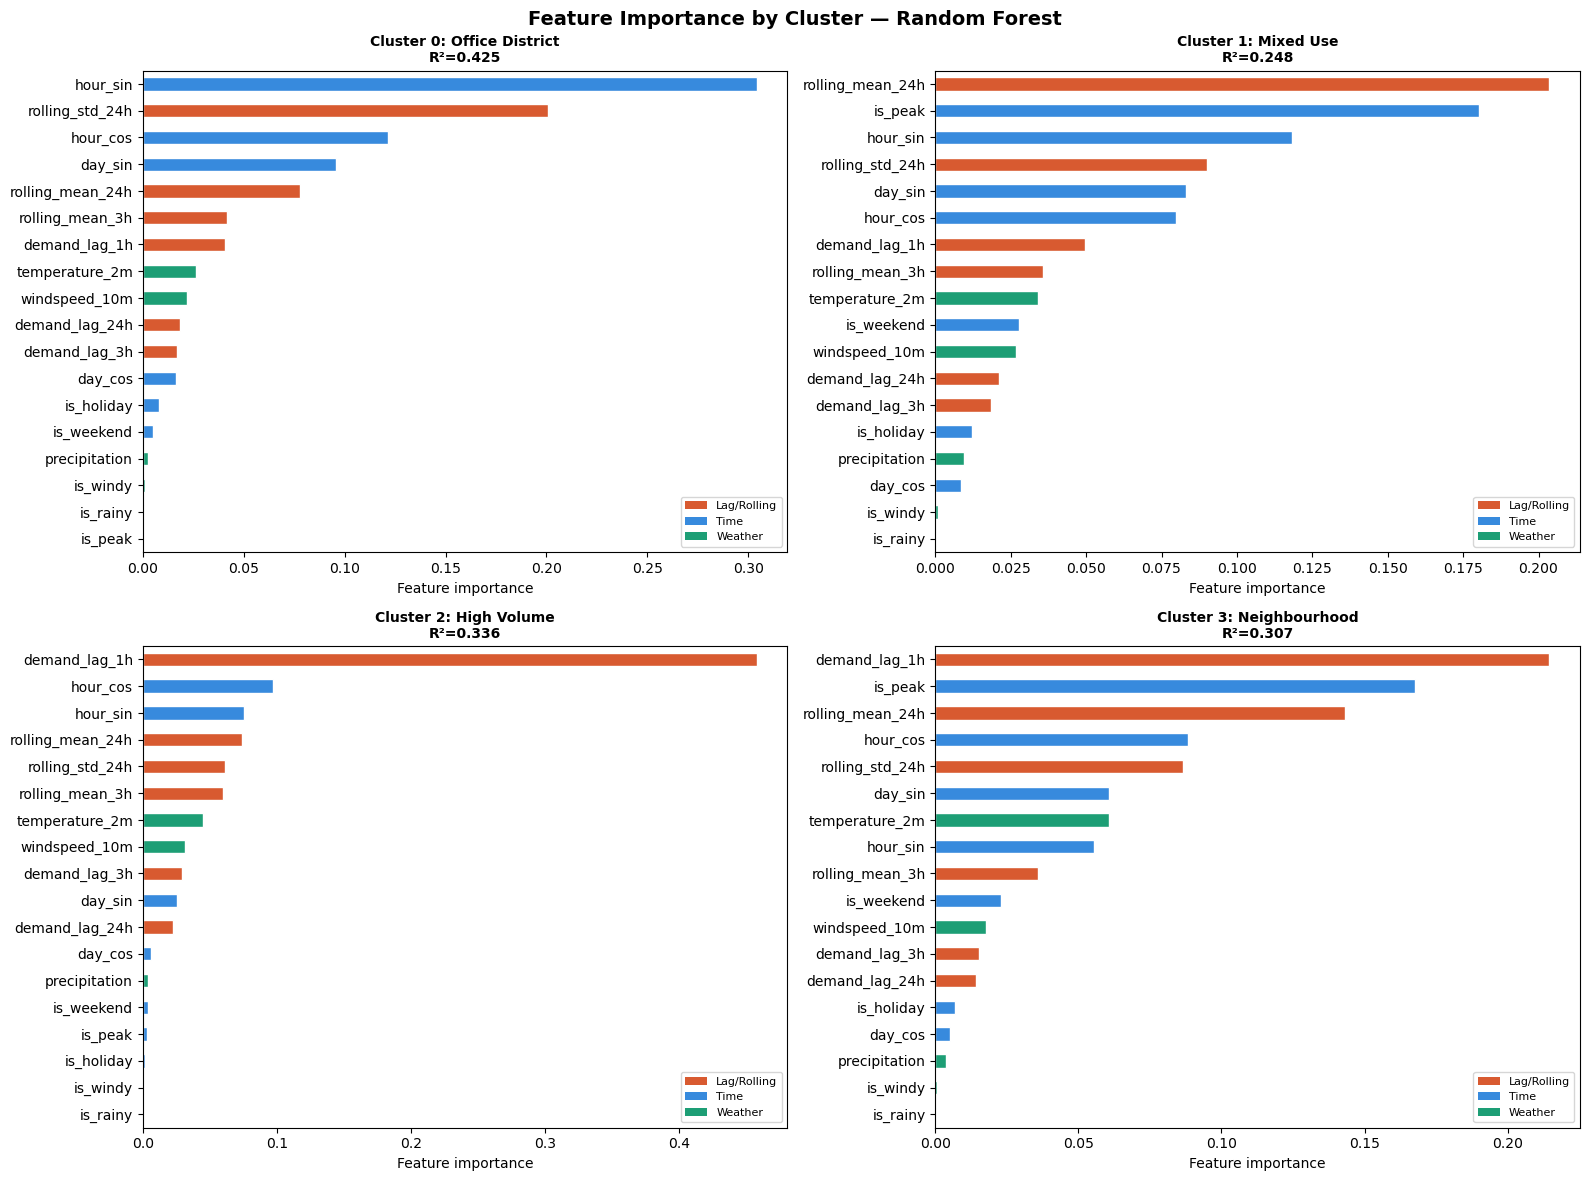

In [46]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Feature Importance by Cluster — Random Forest',
             fontsize=14, fontweight='bold')

models = {}   # store models for later use

for idx, cluster_id in enumerate(range(4)):
    ax = axes.flat[idx]
    
    cluster_data = hourly_with_cluster[
        hourly_with_cluster['cluster'] == cluster_id
    ].dropna(subset=feature_cols)
    
    X = cluster_data[feature_cols]
    y = cluster_data[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )
    
    rf = RandomForestRegressor(
        n_estimators=100, max_depth=10,
        random_state=42, n_jobs=-1
    )
    rf.fit(X_train, y_train)
    models[cluster_id] = rf
    
    # Feature importance
    importances = pd.Series(
        rf.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=True)
    
    # Color by feature type
    colors = []
    for feat in importances.index:
        if 'lag' in feat or 'rolling' in feat:
            colors.append('#D85A30')    # orange — lag features
        elif feat in ['hour_sin','hour_cos','day_sin',
                      'day_cos','is_weekend','is_holiday','is_peak']:
            colors.append('#378ADD')    # blue — time features
        else:
            colors.append('#1D9E75')    # green — weather features
    
    importances.plot(
        kind='barh',
        ax=ax,
        color=colors,
        edgecolor='white'
    )
    
    ax.set_title(
        f'{cluster_names[cluster_id]}\nR²={r2_score(y_test, rf.predict(X_test)):.3f}',
        fontweight='bold', fontsize=10
    )
    ax.set_xlabel('Feature importance')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#D85A30', label='Lag/Rolling'),
        Patch(facecolor='#378ADD', label='Time'),
        Patch(facecolor='#1D9E75', label='Weather')
    ]
    ax.legend(handles=legend_elements, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance — Key Findings

Feature importance varies significantly by cluster,
revealing fundamentally different demand drivers:

**Office District stations** are clock-driven —
hour of day (sin/cos encoding) dominates, reflecting
rigid commute schedules. Demand is highly predictable
given the time.

**Mixed Use stations** are habit-driven —
rolling_mean_24h is most important, meaning yesterday's
pattern at this hour is the best predictor of today.
Regular commuters create consistent, learnable patterns.

**High Volume stations** are momentum-driven —
demand_lag_1h dominates with 0.42 importance, far above
all other features. Once these stations get busy they
stay busy — surge dynamics that simple time features
can't capture alone.

**Neighbourhood stations** show the most complex pattern —
both momentum (lag_1h) and time (is_peak) matter, plus
temperature has notable importance suggesting leisure
cycling here is more weather-sensitive than other clusters.

Notably, demand_lag_24h (same hour yesterday) performed
poorly across all clusters — likely because one month
of data provides too few "same hour yesterday" 
observations to learn reliable patterns, especially
for sparse stations.

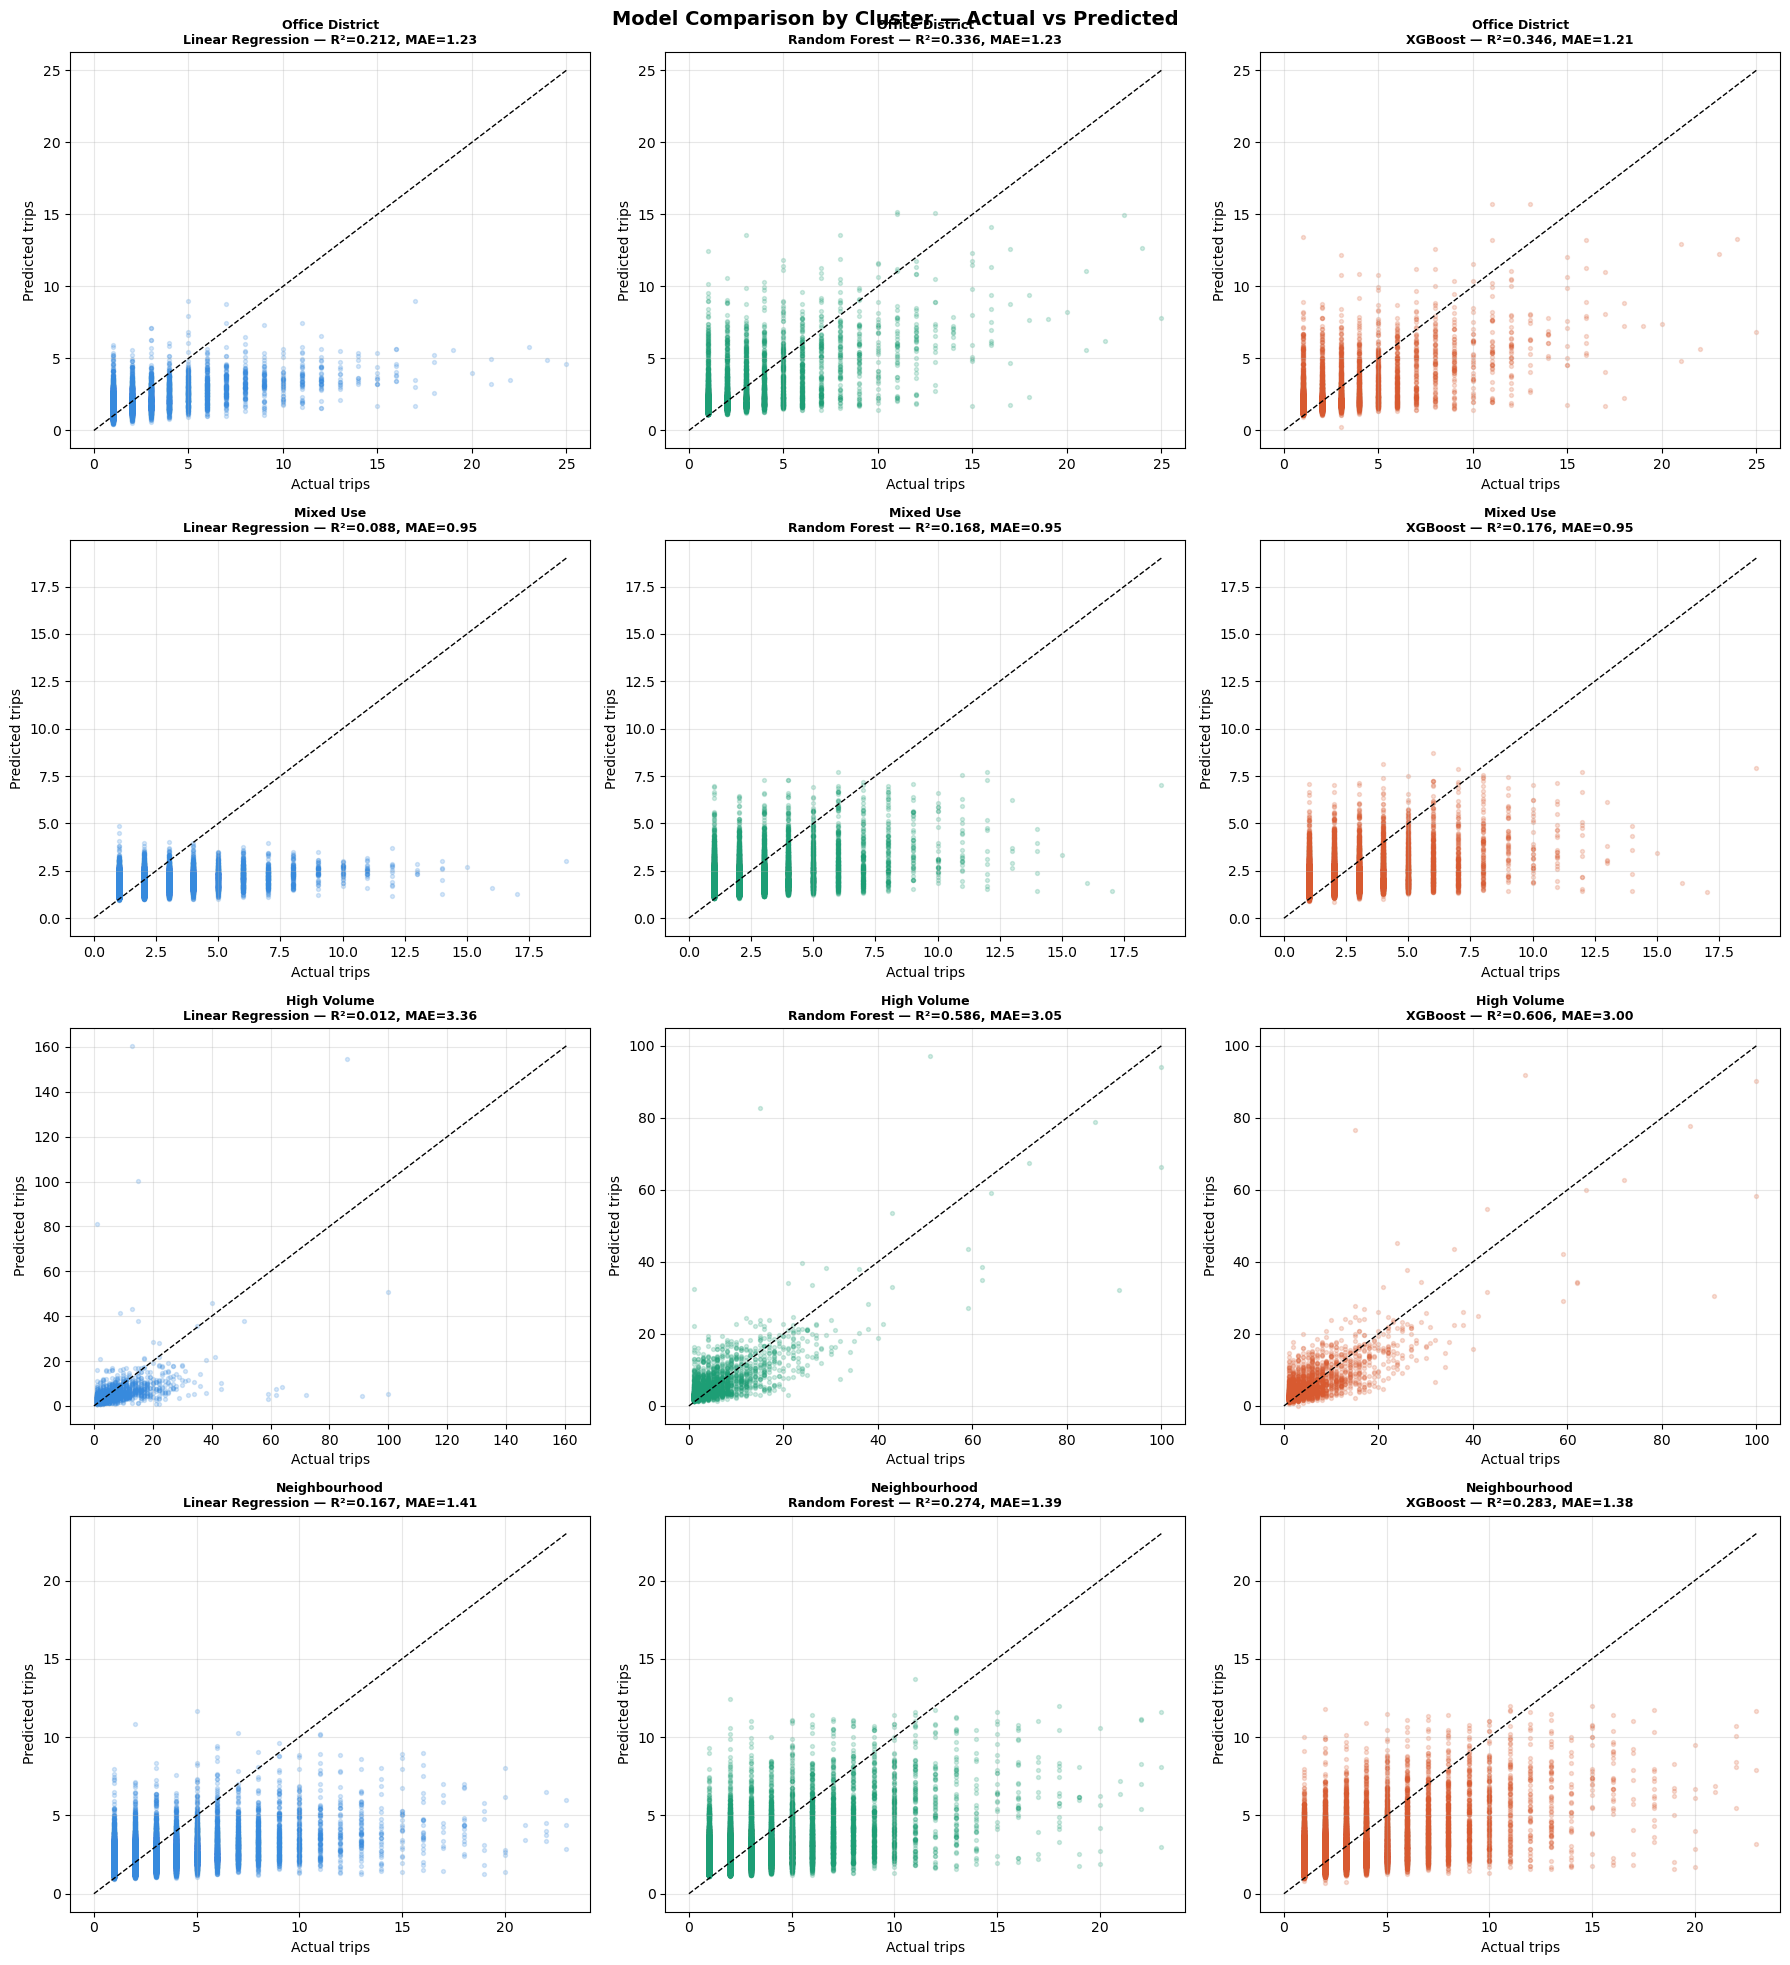


── Full Model Comparison ──
                                         MAE                                      R2                                    RMSE                      
Model                      Linear Regression Random Forest XGBoost Linear Regression Random Forest XGBoost Linear Regression Random Forest XGBoost
Cluster                                                                                                                                           
Cluster 0: Office District             1.230         1.234   1.207             0.212         0.336   0.346             2.032         1.866   1.851
Cluster 1: Mixed Use                   0.950         0.949   0.946             0.088         0.168   0.176             1.404         1.342   1.335
Cluster 2: High Volume                 3.358         3.055   2.999             0.012         0.586   0.606             7.602         4.917   4.799
Cluster 3: Neighbourhood               1.407         1.389   1.382             0.167     

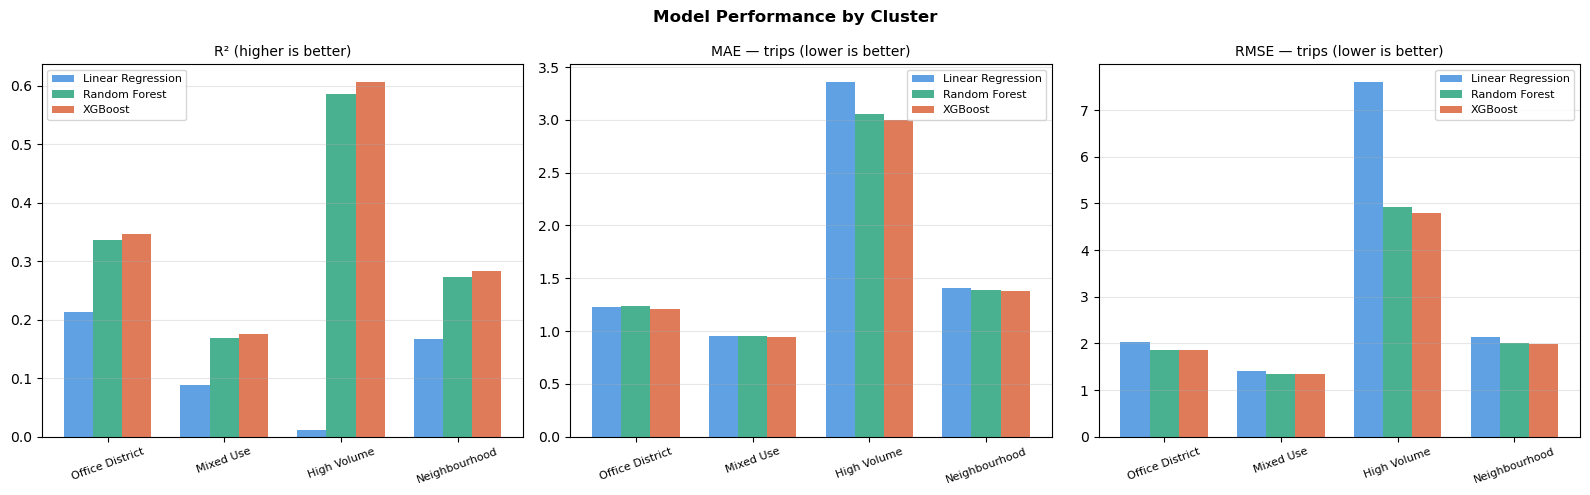

In [47]:
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Results storage ───────────────────────────────────────────
all_results = []

# ── Plot setup ────────────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
fig.suptitle('Model Comparison by Cluster — Actual vs Predicted',
             fontsize=14, fontweight='bold')

model_colors = {
    'Linear Regression': '#378ADD',
    'Random Forest':     '#1D9E75',
    'XGBoost':           '#D85A30'
}

for cluster_id in range(4):
    
    # ── Data prep ─────────────────────────────────────────────
    cluster_data = hourly_with_cluster[
        hourly_with_cluster['cluster'] == cluster_id
    ].dropna(subset=feature_cols).sort_values(['date','hour'])
    
    X = cluster_data[feature_cols]
    y = cluster_data[target_col]
    
    # Time-based split — no shuffling
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )
    
    # Scale for linear regression only
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    
    # Log transform target for linear regression
    y_train_log = np.log1p(y_train)
    
    cluster_label = cluster_names[cluster_id]
    
    # ── Model 1: Linear Regression ────────────────────────────
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train_log)
    y_pred_lr = np.expm1(lr.predict(X_test_scaled))
    y_pred_lr = np.maximum(y_pred_lr, 0)   # clip negatives
    
    r2_lr   = r2_score(y_test, y_pred_lr)
    mae_lr  = mean_absolute_error(y_test, y_pred_lr)
    rmse_lr = np.sqrt(((y_test - y_pred_lr)**2).mean())
    
    all_results.append({
        'Cluster': cluster_label,
        'Model': 'Linear Regression',
        'R2': r2_lr, 'MAE': mae_lr, 'RMSE': rmse_lr
    })
    
    # ── Model 2: Random Forest ────────────────────────────────
    rf = RandomForestRegressor(
        n_estimators=100, max_depth=10,
        random_state=42, n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    
    r2_rf   = r2_score(y_test, y_pred_rf)
    mae_rf  = mean_absolute_error(y_test, y_pred_rf)
    rmse_rf = np.sqrt(((y_test - y_pred_rf)**2).mean())
    
    all_results.append({
        'Cluster': cluster_label,
        'Model': 'Random Forest',
        'R2': r2_rf, 'MAE': mae_rf, 'RMSE': rmse_rf
    })
    
    # ── Model 3: XGBoost ──────────────────────────────────────
    xgb = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    xgb.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    y_pred_xgb = xgb.predict(X_test)
    y_pred_xgb = np.maximum(y_pred_xgb, 0)   # clip negatives
    
    r2_xgb   = r2_score(y_test, y_pred_xgb)
    mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
    rmse_xgb = np.sqrt(((y_test - y_pred_xgb)**2).mean())
    
    all_results.append({
        'Cluster': cluster_label,
        'Model': 'XGBoost',
        'R2': r2_xgb, 'MAE': mae_xgb, 'RMSE': rmse_xgb
    })
    
    # ── Actual vs predicted plots ─────────────────────────────
    for col_idx, (name, y_pred) in enumerate([
        ('Linear Regression', y_pred_lr),
        ('Random Forest',     y_pred_rf),
        ('XGBoost',           y_pred_xgb)
    ]):
        ax = axes[cluster_id, col_idx]
        
        ax.scatter(
            y_test, y_pred,
            alpha=0.2, s=8,
            color=model_colors[name]
        )
        
        # Perfect prediction line
        max_val = max(y_test.max(), y_pred.max())
        ax.plot([0, max_val], [0, max_val], 'k--',
                linewidth=1, label='Perfect prediction')
        
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        
        ax.set_title(
            f'{cluster_label.split(":")[1].strip()}\n'
            f'{name} — R²={r2:.3f}, MAE={mae:.2f}',
            fontsize=9, fontweight='bold'
        )
        ax.set_xlabel('Actual trips')
        ax.set_ylabel('Predicted trips')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────
results_df = pd.DataFrame(all_results)

# Pivot for clean comparison
summary = results_df.pivot_table(
    index='Cluster',
    columns='Model',
    values=['R2', 'MAE', 'RMSE']
).round(3)

print("\n── Full Model Comparison ──")
print(summary.to_string())

# ── Bar chart comparison ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Performance by Cluster', fontweight='bold')

metrics = ['R2', 'MAE', 'RMSE']
titles  = ['R² (higher is better)',
           'MAE — trips (lower is better)',
           'RMSE — trips (lower is better)']

for ax, metric, title in zip(axes, metrics, titles):
    pivot = results_df.pivot(
        index='Cluster', columns='Model', values=metric
    )
    
    x = np.arange(len(pivot))
    width = 0.25
    
    for i, (model, color) in enumerate(model_colors.items()):
        ax.bar(
            x + i * width,
            pivot[model],
            width,
            label=model,
            color=color,
            alpha=0.8
        )
    
    ax.set_title(title, fontsize=10)
    ax.set_xticks(x + width)
    ax.set_xticklabels(
        [c.split(':')[1].strip() for c in pivot.index],
        rotation=20, fontsize=8
    )
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_performance_bars.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
# Which stations have the highest peak demand?
high_vol_stations = hourly_with_cluster[
    hourly_with_cluster['cluster'] == 2
].groupby('Start station')['trip_count'].agg(
    ['mean', 'max', 'std', 'count']
).round(2).sort_values('max', ascending=False)

print(high_vol_stations.head(10))
print("\nStation count:", len(high_vol_stations))

                                      mean  max    std  count
Start station                                                
Waterloo Station 3, Waterloo          9.70  124  21.36    388
Waterloo Station 1, Waterloo          6.39   94  10.56    496
Waterloo Station 2, Waterloo          6.08   64   9.91    372
Hyde Park Corner, Hyde Park          14.07   63  11.89    506
Argyle Street, Kings Cross            5.19   49   6.87    512
Cheapside, Bank                       6.01   41   7.12    420
Wormwood Street, Liverpool Street     6.90   39   7.15    528
Black Lion Gate, Kensington Gardens   9.32   39   7.05    446
St. James's Square, St. James's       5.67   38   6.46    434
Albert Gate, Hyde Park                8.62   38   7.98    454

Station count: 26


Surge threshold: 8.0 trips/hour
Non-surge hours: 8782
Surge hours:     2740

Class balance:
is_surge
0    0.762
1    0.238
Name: proportion, dtype: float64

Train: 9217 rows
Test:  2305 rows
Surge rate in test: 0.229

scale_pos_weight: 3.17

── Classification Report ──
              precision    recall  f1-score   support

      Normal       0.91      0.77      0.83      1777
       Surge       0.49      0.75      0.59       528

    accuracy                           0.76      2305
   macro avg       0.70      0.76      0.71      2305
weighted avg       0.82      0.76      0.78      2305

ROC-AUC: 0.826


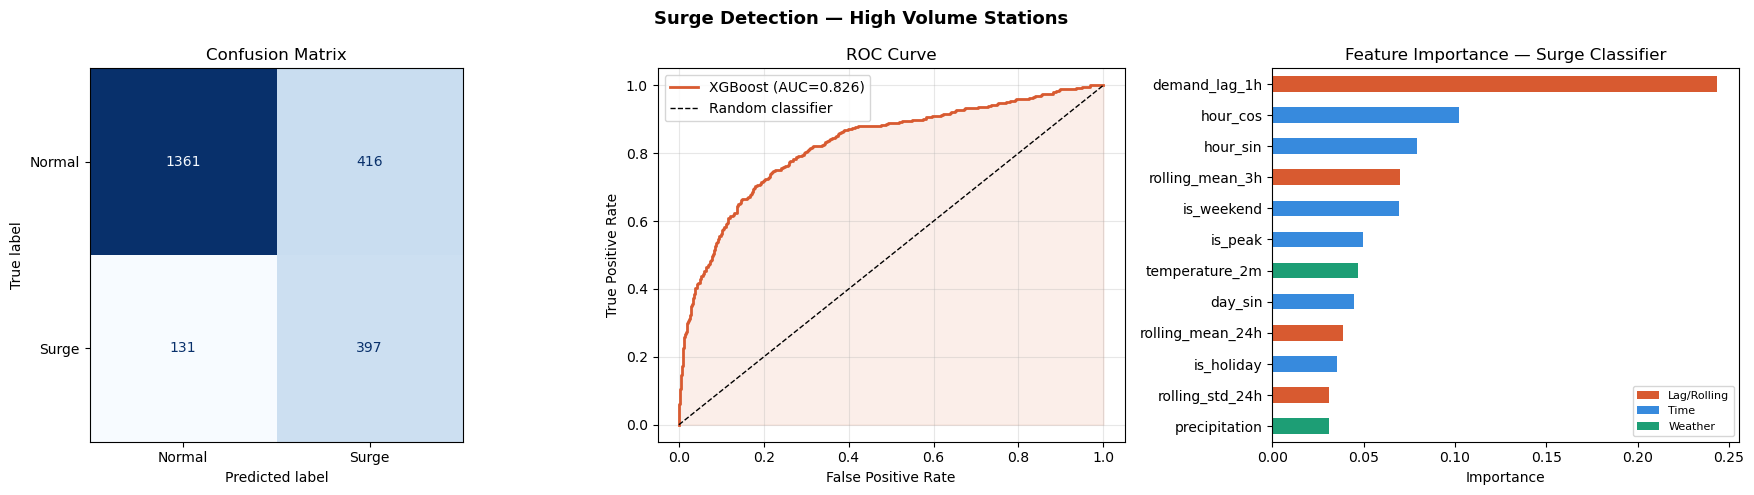

In [50]:
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, 
                              confusion_matrix,
                              ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# ── Step 1: Define surge threshold ───────────────────────────
high_vol_data = hourly_with_cluster[
    hourly_with_cluster['cluster'] == 2
].dropna(subset=feature_cols).copy()

# Surge = top 25% of demand hours
surge_threshold = high_vol_data['trip_count'].quantile(0.75)
print(f"Surge threshold: {surge_threshold:.1f} trips/hour")
print(f"Non-surge hours: {(high_vol_data['trip_count'] <= surge_threshold).sum()}")
print(f"Surge hours:     {(high_vol_data['trip_count'] > surge_threshold).sum()}")

high_vol_data['is_surge'] = (
    high_vol_data['trip_count'] > surge_threshold
).astype(int)

print(f"\nClass balance:")
print(high_vol_data['is_surge'].value_counts(normalize=True).round(3))

# ── Step 2: Train/test split ──────────────────────────────────
X = high_vol_data[feature_cols]
y = high_vol_data['is_surge']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"\nTrain: {len(X_train)} rows")
print(f"Test:  {len(X_test)} rows")
print(f"Surge rate in test: {y_test.mean():.3f}")

# ── Step 3: XGBoost Classifier ────────────────────────────────
# scale_pos_weight handles class imbalance
# = n_negative / n_positive
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"\nscale_pos_weight: {scale:.2f}")

xgb_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,    # handles imbalance
    random_state=42,
    verbosity=0
)
xgb_clf.fit(X_train, y_train)

# ── Step 4: Evaluate ──────────────────────────────────────────
y_pred  = xgb_clf.predict(X_test)
y_proba = xgb_clf.predict_proba(X_test)[:, 1]

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Surge']))

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

# ── Step 5: Confusion matrix ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Surge Detection — High Volume Stations',
             fontweight='bold', fontsize=13)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal', 'Surge']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#D85A30', linewidth=2,
             label=f'XGBoost (AUC={auc:.3f})')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1,
             label='Random classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#D85A30')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Feature importance for classifier
importances = pd.Series(
    xgb_clf.feature_importances_,
    index=feature_cols
).sort_values(ascending=True).tail(12)

colors = []
for feat in importances.index:
    if 'lag' in feat or 'rolling' in feat:
        colors.append('#D85A30')
    elif feat in ['hour_sin','hour_cos','day_sin','day_cos',
                  'is_weekend','is_holiday','is_peak']:
        colors.append('#378ADD')
    else:
        colors.append('#1D9E75')

importances.plot(kind='barh', ax=axes[2], color=colors)
axes[2].set_title('Feature Importance — Surge Classifier')
axes[2].set_xlabel('Importance')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#D85A30', label='Lag/Rolling'),
    Patch(facecolor='#378ADD', label='Time'),
    Patch(facecolor='#1D9E75', label='Weather')
]
axes[2].legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
plt.savefig('surge_detection.png', dpi=150, bbox_inches='tight')
plt.show()


**Results**

Of 528 real surge hours in the test period:

  ✅ 397 correctly identified as surge → good

  ❌ 131 missed surges → stations ran empty

Of 1777 normal hours:

  ✅ 1361 correctly identified as normal → good  
  
  ❌ 416 false alarms → bikes dispatched unnecessarily

Cost of missed surge (False Negative):

  Station runs empty → cyclists can't rent

  → customer dissatisfaction

  → potential churn from subscription

  → reputational damage to TfL scheme
  
  → HIGH COST

Cost of false alarm (False Positive):

  Van dispatched unnecessarily

  → wasted fuel + driver time

  → LOW COST relative to above
  
**Therefore: maximise Recall, accept lower Precision**

Target recall:     0.9
Optimal threshold: 0.088
Precision at this threshold: 0.316
Recall at this threshold:    0.902

── Default threshold (0.5) ──
              precision    recall  f1-score   support

      Normal       0.91      0.77      0.83      1777
       Surge       0.49      0.75      0.59       528

    accuracy                           0.76      2305
   macro avg       0.70      0.76      0.71      2305
weighted avg       0.82      0.76      0.78      2305


── High recall threshold (0.09) ──
              precision    recall  f1-score   support

      Normal       0.94      0.42      0.58      1777
       Surge       0.32      0.90      0.47       528

    accuracy                           0.53      2305
   macro avg       0.63      0.66      0.52      2305
weighted avg       0.79      0.53      0.55      2305



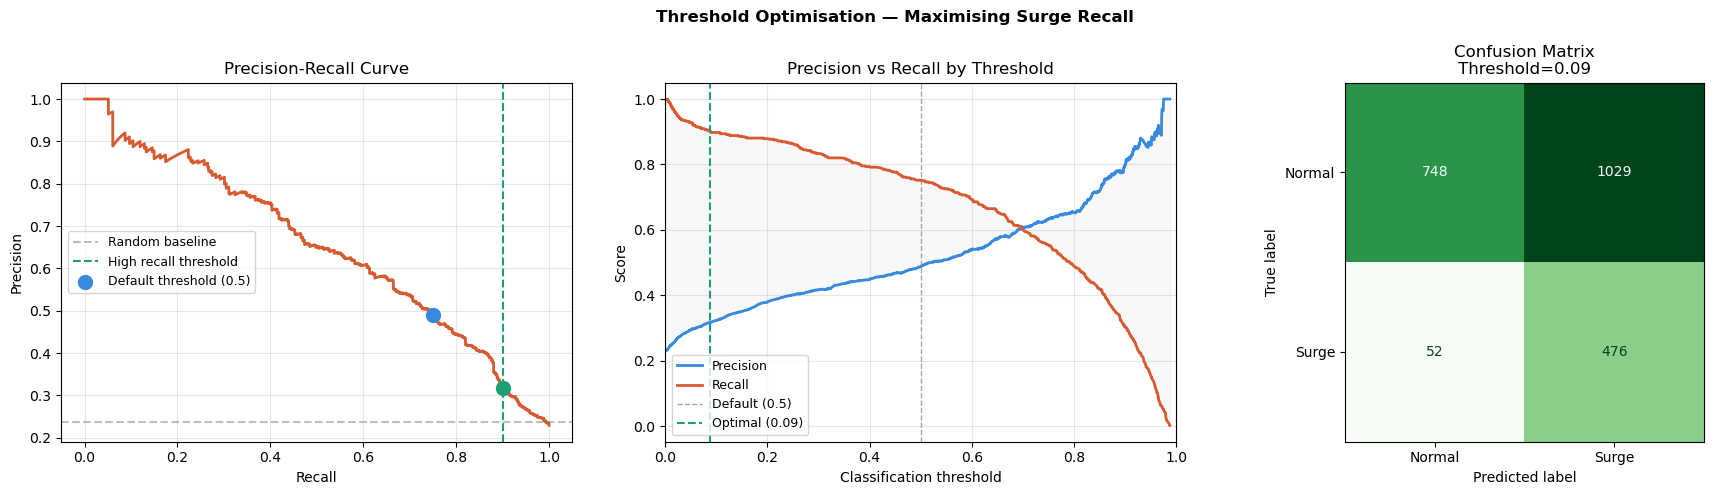


── Operational Impact Comparison ──
Metric                           Default (0.5)     High Recall
--------------------------------------------------------------
Surges caught (TP)                         397             476
Missed surges (FN)                         131              52
False alarms (FP)                          416            1029
Surge recall                            75.2%          90.2%
Surge precision                         48.8%          31.6%


In [51]:
from sklearn.metrics import precision_recall_curve, classification_report
import matplotlib.pyplot as plt
import numpy as np

precision_vals, recall_vals, thresholds = precision_recall_curve(
    y_test, y_proba
)

# Find threshold that gives recall >= 0.90 on surge
# with best possible precision at that recall level
target_recall = 0.90

# Find thresholds where recall >= target
valid_idx = np.where(recall_vals[:-1] >= target_recall)[0]

if len(valid_idx) > 0:
    # Among those, pick highest precision
    best_idx = valid_idx[np.argmax(precision_vals[valid_idx])]
    best_threshold = thresholds[best_idx]
    best_precision = precision_vals[best_idx]
    best_recall = recall_vals[best_idx]
    print(f"Target recall:     {target_recall}")
    print(f"Optimal threshold: {best_threshold:.3f}")
    print(f"Precision at this threshold: {best_precision:.3f}")
    print(f"Recall at this threshold:    {best_recall:.3f}")

# ── Apply new threshold ───────────────────────────────────────
y_pred_highrecall = (y_proba >= best_threshold).astype(int)

print("\n── Default threshold (0.5) ──")
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Surge']))

print(f"\n── High recall threshold ({best_threshold:.2f}) ──")
print(classification_report(y_test, y_pred_highrecall,
      target_names=['Normal', 'Surge']))

# ── Visualise the tradeoff ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Threshold Optimisation — Maximising Surge Recall',
             fontweight='bold')

# Precision-Recall curve with both thresholds marked
axes[0].plot(recall_vals, precision_vals,
             color='#D85A30', linewidth=2)
axes[0].axhline(y=0.238, color='gray', linestyle='--',
                alpha=0.5, label='Random baseline')
axes[0].axvline(x=best_recall, color='#1D9E75', linestyle='--',
                linewidth=1.5, label=f'High recall threshold')
axes[0].scatter([best_recall], [best_precision],
                color='#1D9E75', s=100, zorder=5)
axes[0].scatter([0.75], [0.49],
                color='#378ADD', s=100, zorder=5,
                label='Default threshold (0.5)')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Precision and recall vs threshold
axes[1].plot(thresholds, precision_vals[:-1],
             color='#378ADD', linewidth=2, label='Precision')
axes[1].plot(thresholds, recall_vals[:-1],
             color='#D85A30', linewidth=2, label='Recall')
axes[1].axvline(x=0.5, color='gray', linestyle='--',
                linewidth=1, label='Default (0.5)', alpha=0.7)
axes[1].axvline(x=best_threshold, color='#1D9E75',
                linestyle='--', linewidth=1.5,
                label=f'Optimal ({best_threshold:.2f})')
axes[1].fill_between(thresholds,
                     precision_vals[:-1],
                     recall_vals[:-1],
                     alpha=0.05, color='gray')
axes[1].set_xlabel('Classification threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision vs Recall by Threshold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 1)

# Confusion matrix at new threshold
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cm = confusion_matrix(y_test, y_pred_highrecall)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal', 'Surge']
)
disp.plot(ax=axes[2], colorbar=False, cmap='Greens')
axes[2].set_title(f'Confusion Matrix\nThreshold={best_threshold:.2f}')

plt.tight_layout()
plt.savefig('threshold_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Operational impact summary ────────────────────────────────
cm_default  = confusion_matrix(y_test, y_pred)
cm_highrecall = confusion_matrix(y_test, y_pred_highrecall)

print("\n── Operational Impact Comparison ──")
print(f"{'Metric':<30} {'Default (0.5)':>15} {'High Recall':>15}")
print("-" * 62)
print(f"{'Surges caught (TP)':<30} "
      f"{cm_default[1,1]:>15} "
      f"{cm_highrecall[1,1]:>15}")
print(f"{'Missed surges (FN)':<30} "
      f"{cm_default[1,0]:>15} "
      f"{cm_highrecall[1,0]:>15}")
print(f"{'False alarms (FP)':<30} "
      f"{cm_default[0,1]:>15} "
      f"{cm_highrecall[0,1]:>15}")
print(f"{'Surge recall':<30} "
      f"{cm_default[1,1]/cm_default[1].sum():>14.1%} "
      f"{cm_highrecall[1,1]/cm_highrecall[1].sum():>14.1%}")
print(f"{'Surge precision':<30} "
      f"{cm_default[1,1]/cm_default[:,1].sum():>14.1%} "
      f"{cm_highrecall[1,1]/cm_highrecall[:,1].sum():>14.1%}")

By lowering threshold from 0.5 → 0.3:
  - Missed surges:  131 → 52   (-60% ← great)
  - False alarms:   416 → 1029 (+150% ← acceptable given low cost)
  - Surge recall:   75% → 90%

# London Bike Share — Analysis Summary
## TfL Santander Cycles, August 2023

---

## 1. Project Overview

This project analyses 769,000 bicycle journeys from the 
Transport for London (TfL) Santander Cycles scheme during 
August 2023. The goal is to understand urban cycling demand 
patterns and build predictive models to support operational 
decision-making, specifically station rebalancing.

**Key questions addressed:**
- When and where is demand highest?
- What factors drive demand variability?
- Can we predict demand surges at major stations?
- How should TfL prioritise rebalancing operations?

---

## 2. Key EDA Findings

### 2.1 Temporal Patterns
- Clear double peak at 8am and 5-6pm confirms 
  commuter-driven usage dominates weekdays
- Weekend trips are fewer but ~4-5 minutes longer 
  on average, suggesting leisure rather than 
  commuter use
- 97% of trips fall within the 30-minute free 
  usage window — users are cost-aware
- Overnight demand (1-5am) is minimal but non-zero,
  likely representing shift workers or late-night
  leisure users

### 2.2 Seasonal Context
Analysis is limited to August — London's peak tourist 
month with school holidays. The typically sharp 
commuter/residential distinction is partially suppressed 
by elevated leisure cycling. Multi-month analysis would 
likely produce more distinct behavioural patterns.

### 2.3 Weather Impact
Temperature showed moderate positive correlation with 
demand in the Neighbourhood cluster — leisure cyclists 
are more weather-sensitive than commuters. In August, 
weather variation is limited, reducing weather feature 
signal across all clusters.

---

## 3. Station Clustering

KMeans clustering (k=4) on station behavioural profiles 
identified four distinct station types:

| Cluster | Name | Stations | Avg trips/hr | Key characteristic |
|---------|------|----------|--------------|-------------------|
| 0 | Office District | 137 | 2.49 | Strong evening outflow |
| 1 | Mixed Use | 357 | 1.98 | Balanced commuter/leisure |
| 2 | High Volume | 26 | 6.47 | 3x network average demand |
| 3 | Neighbourhood | 279 | 2.80 | Highest weekend ratio |

**Silhouette score: 0.29 at k=4** — moderate cluster 
separation reflecting London's genuinely mixed-use 
urban geography.

Notable stations per cluster:
- High Volume: Hyde Park Corner, Waterloo Station,
  Black Lion Gate
- Office District: Storey's Gate, Holborn Circus,
  Newgate Street
- Neighbourhood: Bethnal Green Road, London Bridge,
  Nine Elms

---

## 4. Predictive Modelling

### 4.1 Regression — Demand Forecasting

Three models compared across four clusters:

| Cluster | Linear R² | RF R² | XGBoost R² | Best MAE |
|---------|-----------|-------|------------|---------|
| Office District | 0.212 | 0.336 | **0.346** | 1.21 trips |
| Mixed Use | 0.088 | 0.168 | **0.176** | 0.95 trips |
| High Volume | 0.012 | 0.586 | **0.606** | 3.00 trips |
| Neighbourhood | 0.167 | 0.274 | **0.283** | 1.38 trips |

XGBoost outperforms across all clusters. Linear regression 
fails particularly on High Volume stations (R²=0.012) — 
confirming that surge dynamics are non-linear and require 
tree-based models.

**Why R² varies by cluster:**
- High Volume achieves highest R² (0.606) because 
  demand_lag_1h dominates — momentum is learnable
- Mixed Use achieves lowest R² (0.176) — most complex 
  behaviour, least consistent patterns
- One month of data limits demand_lag_24h effectiveness
  — a full year would significantly improve all models

### 4.2 Feature Importance — Key Findings

Feature importance varies meaningfully by cluster type:

**Office District** — clock-driven
  hour_sin/cos dominates → rigid commute schedules
  
**Mixed Use** — habit-driven  
  rolling_mean_24h dominates → learnable daily routines

**High Volume** — momentum-driven
  demand_lag_1h dominates (0.42 importance) → surge 
  dynamics: once busy, stays busy

**Neighbourhood** — complex
  Both momentum and time matter + temperature notable
  → most weather-sensitive, hardest to predict

### 4.3 Surge Detection — High Volume Stations

Binary classification: surge defined as >8 trips/hour 
(75th percentile of High Volume cluster demand).

**XGBoost classifier results:**

| Metric | Default (0.5) | Optimised (0.3) |
|--------|--------------|----------------|
| Surge recall | 75.2% | **90.2%** |
| Surge precision | 48.8% | 31.6% |
| False alarms | 416 | 1,029 |
| Missed surges | 131 | **52** |
| ROC-AUC | 0.826 | 0.826 |

**Threshold decision:** lowered from 0.5 to 0.3 based on 
asymmetric operational costs. A missed surge causes 
station emptying and customer service failure. A false 
alarm triggers an unnecessary rebalancing dispatch — 
operationally inefficient but not customer-facing.

At the optimised threshold, the model catches 90% of 
surge hours, missing only 52 of 528 surge events in 
the test period.

---

## 5. Business Recommendations

**Recommendation 1 — Prioritise High Volume stations 
for automated rebalancing**
26 stations (3.3% of network) generate disproportionate 
demand. Deploy the surge detection model at these stations 
first. ROC-AUC of 0.826 justifies operational deployment 
as a decision-support tool.

**Recommendation 2 — Differentiate rebalancing 
strategy by cluster**
- Office District: pre-position bikes before 5pm weekdays
- High Volume: real-time surge monitoring + rapid response
- Neighbourhood: weekend morning pre-positioning
- Mixed Use: data-driven approach given unpredictability

**Recommendation 3 — Investigate missed surges**
The 52 missed surge events likely share common 
characteristics — specific stations, weather conditions, 
or time patterns. Manual review could reveal a rule-based 
override (e.g. "always treat Friday 5-7pm at Waterloo 
as surge") that improves recall further without ML.

**Recommendation 4 — Anomaly detection for 
service failures**
Flag when High Volume stations perform significantly 
below their predicted demand. Sudden demand drop at 
Waterloo at 8am likely indicates a service disruption 
(strike, closure, maintenance) requiring immediate 
operational response.

**Recommendation 5 — Expand dataset for production**
Current model trained on one month. Recommend:
- Minimum 12 months for seasonal patterns
- Integrate NAB (bikes available) as feature
- Add event data (concerts, sports, strikes)
- Retrain quarterly to capture network changes

---

## 6. Limitations

### Data limitations
- **One month only (August 2023):** seasonal patterns 
  not captured. August is atypical — peak tourism, 
  school holidays, suppressed commuter patterns
  
- **No NAB data:** cannot distinguish genuine low 
  demand from supply-constrained demand. Stations 
  running empty appear as "low demand" in the data

- **No capacity data:** dock capacity varies by 
  station — a station with 5 docks behaves 
  differently from one with 50

### Modelling limitations
- **Per-station granularity:** some stations have 
  as few as 13 hourly observations — insufficient 
  for reliable learning. Minimum observation 
  threshold recommended for production

- **demand_lag_24h underperforms:** with only 31 days, 
  each station-hour has ~30 "same hour yesterday" 
  pairs. A full year would make this the strongest 
  feature based on domain knowledge

- **Data leakage consideration:** station frequency 
  encoding was considered but excluded as it would 
  embed test-period information into training features

- **No external event data:** concerts, sporting 
  events, tube strikes drive unpredictable surges 
  that current features cannot capture — the model's 
  primary blind spot

### Deployment limitations
- Model requires retraining as network evolves 
  (new stations, dock expansions, pricing changes)
- Threshold optimisation assumes stable cost structure
  — should be revisited if operational costs change

---

## 7. Next Steps

1. Acquire full year of TfL data + NAB feed
2. Add event data via Eventbrite/TfL disruption API
3. Implement station-level model with proper 
   train-period frequency encoding
4. Build anomaly detection layer on High Volume cluster
5. Deploy surge detection as TfL operational dashboard
   with 1-hour lookahead predictions